# The Comprehensive Pandas Masterclass
## From Zero to Advanced — With Real-World Nigerian E-Commerce Data

---

**Instructor:** Prodigy Training Hub  
**Programme:** Python for Data Analysis  
**Level:** Beginner → Intermediate → Advanced  
**Dataset:** Nigeria E-Commerce Sales Dataset (515 records, 18 columns)

---

## What You Will Learn

This notebook is your complete, end-to-end guide to **Pandas** — the most important Python library for data analysis. Whether you are a student opening Python for the first time, or a working professional who wants to sharpen your skills, this notebook has been designed for every level.

By the time you finish, you will be able to:

- Understand what Pandas is and why it matters in the real world
- Create, load, and navigate data using Pandas
- Clean messy, real-world data (missing values, duplicates, wrong formats)
- Analyse and summarise data to extract meaningful insights
- Visualise data with Pandas built-in plotting tools
- Apply advanced operations: groupby, pivot tables, merging, time series, and more

---

## The Dataset We Use

We work with a **Nigerian E-Commerce Sales Dataset** that simulates real transactions across platforms like Jumia, Konga, Jiji, and Flutterwave Store.

| Column | Description |
|---|---|
| `order_id` | Unique order identifier |
| `order_date` | Date the order was placed |
| `state` | Nigerian state of the customer |
| `region` | Geo-political zone |
| `platform` | E-commerce platform used |
| `category` | Product category |
| `product_name` | Product name |
| `unit_price` | Price per unit in Naira |
| `quantity` | Number of items ordered |
| `discount_pct` | Discount applied (%) |
| `total_amount` | Final amount paid |
| `payment_method` | How the customer paid |
| `customer_age` | Age of the customer (has missing values) |
| `customer_gender` | Gender |
| `customer_segment` | New / Regular / Premium / VIP |
| `rating` | Customer rating 1–5 (has missing values) |
| `delivery_days` | Days to deliver (has dirty outliers) |
| `returned` | Whether the item was returned |

The dataset intentionally contains **missing values**, **duplicate rows**, and **dirty data** — just like the real world.

---

> **How to use this notebook:** Read every markdown cell carefully before running the code cell below it. Every line of code is explained. Do not skip sections — each builds on the previous one.

---

---
# SECTION 1: Introduction to Pandas

---

## 1.1 What Is Pandas?

**Pandas** is an open-source Python library created by **Wes McKinney in 2008** while he was working at a financial data firm called AQR Capital Management. The name comes from **"Panel Data"** — a term from econometrics for multi-dimensional structured datasets.

Today, Pandas is one of the most downloaded Python packages in the world. It is the foundation of almost every data analysis, data science, and machine learning project in Python.

### Why Is Pandas So Important?

Before Pandas, working with structured data in Python was painful. You had to use nested lists, loops, and manual index tracking just to do basic operations. Pandas changed everything by giving us:

1. **The DataFrame** — a table-like structure (like an Excel spreadsheet or a database table) built into Python
2. **The Series** — a labelled one-dimensional array (like a single column)
3. **Powerful built-in tools** for loading, cleaning, transforming, aggregating, and visualising data
4. **Integration** with NumPy, Matplotlib, Scikit-learn, and virtually every other Python data tool

### Where Is Pandas Used?

| Industry | Use Case |
|---|---|
| Banking & Finance | Transaction analysis, fraud detection, reporting |
| Healthcare | Patient records, clinical trial data |
| Retail & E-Commerce | Sales analysis, inventory, customer segmentation |
| Government | Census data, public records |
| Research | Scientific datasets, survey analysis |

---

## 1.2 Installing and Importing Pandas

Pandas does not come with standard Python. You install it once using pip:

```bash
pip install pandas
```

Once installed, you import it into your notebook. By convention, Pandas is always imported as `pd` — this is a universal community standard.

We also import **NumPy** (as `np`) — the numerical computing library that Pandas is built on top of.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.1 — Importing Libraries
# ─────────────────────────────────────────────────────────────────

# pandas: the main data analysis library — always imported as pd
import pandas as pd

# numpy: numerical operations, underpins pandas — always imported as np
import numpy as np

# matplotlib: the foundational Python plotting library
import matplotlib.pyplot as plt

# This magic command tells Jupyter to display charts inside the notebook
%matplotlib inline

# Apply a clean plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Verify the versions installed
print("Pandas version  :", pd.__version__)
print("NumPy version   :", np.__version__)
print("Libraries loaded successfully!")

Pandas version  : 2.3.1
NumPy version   : 2.3.1
Libraries loaded successfully!


---
## 1.3 The Two Core Pandas Data Structures

Pandas is built around two primary data structures. Understanding them is the most important first step.

---

### 1.3.1 The Pandas Series

A **Series** is a **one-dimensional labelled array**. Think of it as a single column in a spreadsheet.

Every Series has:
- **Values** — the actual data
- **Index** — labels for each value (by default: 0, 1, 2, 3...)
- **Name** — optional label for the Series itself
- **dtype** — the data type of the values

```
Index    Value
  0      24500
  1      18000
  2      55000
  3      9800
Name: unit_price, dtype: float64
```

The index is what makes a Series different from a plain Python list. It allows you to access data by label.

In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.2 — Creating a Series from a List
# ─────────────────────────────────────────────────────────────────

# The simplest way: create from a Python list.
# Pandas automatically assigns integer indices starting from 0.

sales_figures = pd.Series([245000, 180000, 320000, 95000, 410000])

print("=== Series from a list ===")
print(sales_figures)
print()
print("Data type   :", sales_figures.dtype)
print("Total items :", len(sales_figures))

=== Series from a list ===
0    245000
1    180000
2    320000
3     95000
4    410000
dtype: int64

Data type   : int64
Total items : 5


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.3 — Series with a Custom Index
# ─────────────────────────────────────────────────────────────────

# Assign your own labels to the index.
# This makes data much more readable and meaningful.

monthly_revenue = pd.Series(
    data  = [245000, 180000, 320000, 95000, 410000, 380000],
    index = ['January', 'February', 'March', 'April', 'May', 'June'],
    name  = 'Monthly Revenue (Naira)'
)

print("=== Series with custom index ===")
print(monthly_revenue)
print()

# Access by label (index name)
print("Revenue for March  :", monthly_revenue['March'])

# Access by position (like a list, 0-indexed)
print("First month revenue:", monthly_revenue.iloc[0])

=== Series with custom index ===
January     245000
February    180000
March       320000
April        95000
May         410000
June        380000
Name: Monthly Revenue (Naira), dtype: int64

Revenue for March  : 320000
First month revenue: 245000


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.4 — Series from a Dictionary
# ─────────────────────────────────────────────────────────────────

# A dictionary maps keys to values — perfect for creating a Series.
# Dictionary keys automatically become the index labels.

platform_orders = pd.Series({
    'Jumia'             : 1245,
    'Konga'             : 876,
    'Jiji'              : 654,
    'Flutterwave Store' : 432,
    'WhatsApp Commerce' : 298
})

print("=== Orders by Platform ===")
print(platform_orders)
print()
print("Total orders         :", platform_orders.sum())
print("Platform with most   :", platform_orders.idxmax())
print("Platform with fewest :", platform_orders.idxmin())

=== Orders by Platform ===
Jumia                1245
Konga                 876
Jiji                  654
Flutterwave Store     432
WhatsApp Commerce     298
dtype: int64

Total orders         : 3505
Platform with most   : Jumia
Platform with fewest : WhatsApp Commerce


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.5 — Series Arithmetic (Vectorised Operations)
# ─────────────────────────────────────────────────────────────────

# One of the great powers of Pandas: arithmetic works element-by-element
# automatically — this is called 'vectorisation'. No loops needed!

prices    = pd.Series([15000, 35000, 8000, 120000, 4500])
quantities = pd.Series([2,     1,     5,   1,       3   ])

# Multiply every price by its corresponding quantity
revenue = prices * quantities

print("Prices     :", prices.tolist())
print("Quantities :", quantities.tolist())
print("Revenue    :", revenue.tolist())
print()

# Apply a 10% discount to all prices at once
discounted = prices * 0.90
print("After 10% discount:", discounted.tolist())

Prices     : [15000, 35000, 8000, 120000, 4500]
Quantities : [2, 1, 5, 1, 3]
Revenue    : [30000, 35000, 40000, 120000, 13500]

After 10% discount: [13500.0, 31500.0, 7200.0, 108000.0, 4050.0]


---
### 1.3.2 The Pandas DataFrame

A **DataFrame** is a **two-dimensional labelled data structure** — think of it as a complete spreadsheet or database table. It has:

- **Rows** — each row is one record / observation
- **Columns** — each column is one variable / feature
- **Row Index** — labels for each row (default: 0, 1, 2...)
- **Column names** — labels for each column
- **Multiple dtypes** — different columns can hold different data types

A DataFrame is essentially a collection of Series that all share the same index. Each column of a DataFrame is a Series.

```
   order_id    state    category     unit_price  quantity  total_amount
0  ORD-100000  Lagos    Electronics  85000.0      1         85000.0
1  ORD-100001  Abuja    Fashion      12500.0      2         25000.0
2  ORD-100002  Kano     Groceries    3200.0       3          9600.0
```

The DataFrame is the single most important object in Pandas.

In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.6 — Creating a DataFrame from a Dictionary
# ─────────────────────────────────────────────────────────────────

# Most common manual creation method: pass a Python dictionary.
# Keys become column names; lists become the column data.

sample_df = pd.DataFrame({
    'order_id' : ['ORD-001',       'ORD-002',    'ORD-003',      'ORD-004',   'ORD-005' ],
    'customer' : ['Chidi Okonkwo', 'Amina Bello','Tunde Adeyemi','Ngozi Obi', 'Emeka Eze'],
    'state'    : ['Lagos',         'Abuja',       'Kano',         'Enugu',     'Rivers'  ],
    'product'  : ['Laptop',        'Hijab',       'Rice (50kg)',  'Textbook',  'Smartphone'],
    'price'    : [350000,          8500,          28000,          4500,        185000    ],
    'quantity' : [1,               3,             2,              5,           1         ],
    'paid'     : [True,            True,          False,          True,        True      ]
})

print("=== Our First DataFrame ===")
print(sample_df)
print()
print("Shape (rows, columns):", sample_df.shape)
print("Column names:", sample_df.columns.tolist())

=== Our First DataFrame ===
  order_id       customer   state      product   price  quantity   paid
0  ORD-001  Chidi Okonkwo   Lagos       Laptop  350000         1   True
1  ORD-002    Amina Bello   Abuja        Hijab    8500         3   True
2  ORD-003  Tunde Adeyemi    Kano  Rice (50kg)   28000         2  False
3  ORD-004      Ngozi Obi   Enugu     Textbook    4500         5   True
4  ORD-005      Emeka Eze  Rivers   Smartphone  185000         1   True

Shape (rows, columns): (5, 7)
Column names: ['order_id', 'customer', 'state', 'product', 'price', 'quantity', 'paid']


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.7 — Key DataFrame Attributes
# ─────────────────────────────────────────────────────────────────

# Every DataFrame exposes these attributes — learn them well.

print("shape  :", sample_df.shape)     # (rows, columns) tuple
print("ndim   :", sample_df.ndim)      # always 2 for DataFrames
print("size   :", sample_df.size)      # total cells = rows x cols
print()
print("=== Data Type of Each Column (dtypes) ===")
print(sample_df.dtypes)
print()
print("=== Row Index ===")
print(sample_df.index)

shape  : (5, 7)
ndim   : 2
size   : 35

=== Data Type of Each Column (dtypes) ===
order_id    object
customer    object
state       object
product     object
price        int64
quantity     int64
paid          bool
dtype: object

=== Row Index ===
RangeIndex(start=0, stop=5, step=1)


---
# SECTION 2: Reading and Loading Real Data

---

## 2.1 Why Reading Data Matters

In the real world, you rarely create DataFrames from scratch. Data comes to you from:

- **CSV files** — the most common data exchange format
- **Excel files** — very common in Nigerian businesses
- **JSON files** — common in web APIs
- **SQL databases** — enterprise and banking systems

Pandas reads all of these with a single line of code.

---

## 2.2 Reading CSV Files

`pd.read_csv()` is the most used function in Pandas. It reads a CSV file and returns a DataFrame.

Key parameters:

| Parameter | What it does | Example |
|---|---|---|
| `parse_dates` | Auto-convert to datetime | `parse_dates=['order_date']` |
| `index_col` | Column to use as row index | `index_col='order_id'` |
| `usecols` | Load only specific columns | `usecols=['name','price']` |
| `nrows` | Load only n rows | `nrows=100` |
| `na_values` | Extra strings to treat as NaN | `na_values=['N/A','--']` |

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.1 — Load the Nigeria E-Commerce Dataset
# ─────────────────────────────────────────────────────────────────

# pd.read_csv() reads a CSV and returns a DataFrame.
# This is the single most used function in Pandas.

df = pd.read_csv('nigeria_ecommerce_sales.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

FileNotFoundError: [Errno 2] No such file or directory: 'nigeria_ecommerce_sales.csv'

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.2 — head() and tail(): Your First Look at the Data
# ─────────────────────────────────────────────────────────────────

# head(n) shows the FIRST n rows. Default n=5.
# Always run this immediately after loading a dataset.
print("=== First 5 rows ===")
print(df.head())
print()

# tail(n) shows the LAST n rows.
# Useful to confirm the file was fully loaded.
print("=== Last 5 rows ===")
print(df.tail())

=== First 5 rows ===
     order_id  order_date   state       region           platform   category  \
0  ORD-100000  2023-01-01  Kaduna   North-West  Flutterwave Store     Sports   
1  ORD-100001  2023-01-02  Rivers  South-South  Flutterwave Store  Furniture   
2  ORD-100002  2023-01-03     Oyo   South-West              Jumia  Furniture   
3  ORD-100003  2023-01-05  Kaduna   North-West  WhatsApp Commerce     Beauty   
4  ORD-100004  2023-01-06    Kano   North-West               Jiji     Sports   

  product_name  unit_price  quantity  discount_pct  total_amount  \
0    Product_0    84684.92         4            15     287928.73   
1    Product_1   279645.77         2            20     447433.23   
2    Product_2   172025.62         3             0     516076.86   
3    Product_3    20493.84         5            15      87098.82   
4    Product_4    83113.55         5            15     353232.59   

    payment_method  customer_age customer_gender customer_segment  rating  \
0  Pay on De

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.3 — info(): Column Types and Missing Values
# ─────────────────────────────────────────────────────────────────

# info() is the single most informative inspection command.
# It shows:
#   - Column names
#   - Non-null counts (how many values are NOT missing)
#   - Data type of each column
#   - Memory usage

print("=== df.info() ===")
df.info()

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          515 non-null    str    
 1   order_date        515 non-null    str    
 2   state             515 non-null    str    
 3   region            515 non-null    str    
 4   platform          515 non-null    str    
 5   category          515 non-null    str    
 6   product_name      515 non-null    str    
 7   unit_price        515 non-null    float64
 8   quantity          515 non-null    int64  
 9   discount_pct      515 non-null    int64  
 10  total_amount      515 non-null    float64
 11  payment_method    515 non-null    str    
 12  customer_age      489 non-null    float64
 13  customer_gender   515 non-null    str    
 14  customer_segment  515 non-null    str    
 15  rating            492 non-null    float64
 16  delivery_days     515 non-null    flo

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.4 — describe(): Statistical Summary
# ─────────────────────────────────────────────────────────────────

# describe() computes summary statistics for numeric columns:
# count, mean, std, min, 25%, 50% (median), 75%, max

print("=== Numeric Columns Summary ===")
print(df.describe().round(2))
print()

# Include ALL columns (text/categorical too) with include='all'
print("=== All Columns Summary ===")
print(df.describe(include='all'))

=== Numeric Columns Summary ===
       unit_price  quantity  discount_pct  total_amount  customer_age  rating  \
count      515.00    515.00        515.00        515.00        489.00  492.00   
mean    111872.22      2.35          7.35     248277.40         39.40    3.08   
std     161192.08      1.41          7.45     473876.90         13.85    1.43   
min        647.83      1.00          0.00        647.83         16.00    1.00   
25%       8279.15      1.00          0.00      16084.45         28.00    2.00   
50%      30504.27      2.00          5.00      57922.85         39.00    3.00   
75%     152119.88      3.00         15.00     265692.82         51.00    4.00   
max     776984.51      5.00         20.00    3487694.40         64.00    5.00   

       delivery_days  
count         515.00  
mean           16.42  
std            97.46  
min             1.00  
25%             3.50  
50%             7.00  
75%            10.00  
max           999.00  

=== All Columns Summary ===
  

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.5 — Additional Inspection Commands
# ─────────────────────────────────────────────────────────────────

# sample(n) — n random rows (great for a random peek)
print("=== 3 Random Rows ===")
print(df.sample(3, random_state=42))
print()

# All column names as a Python list
print("=== Column Names ===")
print(df.columns.tolist())
print()

# Shape
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print()

# dtypes — data type of every column
print("=== Data Types ===")
print(df.dtypes)

=== 3 Random Rows ===
       order_id  order_date   state         region           platform  \
304  ORD-100304  2024-03-20   Abuja  North-Central               Jiji   
499  ORD-100499  2024-12-31  Rivers    South-South  WhatsApp Commerce   
441  ORD-100441  2024-10-07   Enugu     South-East  Flutterwave Store   

             category product_name  unit_price  quantity  discount_pct  \
304  Phones & Tablets  Product_304   359459.96         1             0   
499         Groceries  Product_499     3845.04         2             0   
441         Furniture  Product_441   288234.55         3             0   

     total_amount payment_method  customer_age customer_gender  \
304     359459.96           USSD          34.0            Male   
499       7690.08            POS          64.0          Female   
441     864703.65            POS          62.0          Female   

    customer_segment  rating  delivery_days  returned  
304          Premium     1.0           11.0     False  
499        

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.6 — Reading CSV with parse_dates and index_col
# ─────────────────────────────────────────────────────────────────

# parse_dates: automatically converts specified columns to datetime objects
# index_col: use a column as the row index instead of the default 0,1,2...

df_parsed = pd.read_csv(
    'nigeria_ecommerce_sales.csv',
    parse_dates=['order_date'],
    index_col='order_id'
)

print("=== Using parse_dates and index_col ===")
print(df_parsed.head(3))
print()
print("order_date dtype:", df_parsed['order_date'].dtype)
print("Index (first 5) :", df_parsed.index[:5].tolist())

=== Using parse_dates and index_col ===
           order_date   state       region           platform   category  \
order_id                                                                   
ORD-100000 2023-01-01  Kaduna   North-West  Flutterwave Store     Sports   
ORD-100001 2023-01-02  Rivers  South-South  Flutterwave Store  Furniture   
ORD-100002 2023-01-03     Oyo   South-West              Jumia  Furniture   

           product_name  unit_price  quantity  discount_pct  total_amount  \
order_id                                                                    
ORD-100000    Product_0    84684.92         4            15     287928.73   
ORD-100001    Product_1   279645.77         2            20     447433.23   
ORD-100002    Product_2   172025.62         3             0     516076.86   

             payment_method  customer_age customer_gender customer_segment  \
order_id                                                                     
ORD-100000  Pay on Delivery          

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.7 — Exporting Data to CSV, Excel, and JSON
# ─────────────────────────────────────────────────────────────────

# to_csv() saves a DataFrame to a CSV file.
# index=False — do NOT write the row index as a column.
df.head(20).to_csv('sample_export.csv', index=False)
print("Saved 20 rows to sample_export.csv")

# to_json() saves to JSON format.
# orient='records' writes each row as a JSON object.
df.head(10).to_json('sample_export.json', orient='records', indent=2)
print("Saved 10 rows to sample_export.json")

# to_excel() saves to Excel (requires openpyxl: pip install openpyxl)
# df.head(20).to_excel('sample_export.xlsx', index=False, sheet_name='Sales')
# print("Saved to Excel")

Saved 20 rows to sample_export.csv
Saved 10 rows to sample_export.json


---
# SECTION 3: Selecting and Indexing Data

---

## 3.1 Selecting Columns

Use square brackets `[]` to select columns.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.1 — Selecting a Single Column (returns a Series)
# ─────────────────────────────────────────────────────────────────

# Single column → returns a Series (NOT a DataFrame)
state_col = df['state']

print("Type:", type(state_col))
print()
print(state_col.head(8))

Type: <class 'pandas.Series'>

0    Kaduna
1    Rivers
2       Oyo
3    Kaduna
4      Kano
5     Enugu
6       Oyo
7       Oyo
Name: state, dtype: str


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.2 — Selecting Multiple Columns (returns a DataFrame)
# ─────────────────────────────────────────────────────────────────

# Multiple columns → pass a LIST of names inside double brackets [[...]]
# This returns a DataFrame, not a Series

key_cols = df[['order_id', 'state', 'category', 'total_amount']]

print("Type:", type(key_cols))
print()
print(key_cols.head(6))

Type:

 <class 'pandas.DataFrame'>

     order_id   state     category  total_amount
0  ORD-100000  Kaduna       Sports     287928.73
1  ORD-100001  Rivers    Furniture     447433.23
2  ORD-100002     Oyo    Furniture     516076.86
3  ORD-100003  Kaduna       Beauty      87098.82
4  ORD-100004    Kano       Sports     353232.59
5  ORD-100005   Enugu  Electronics      55581.34


---
## 3.2 Selecting Rows: .loc vs .iloc

| Selector | Uses | Description |
|---|---|---|
| `.loc[]` | Labels / names | Row label AND column name |
| `.iloc[]` | Integer positions | Row number AND column number (0-indexed) |

When the index is 0, 1, 2... (the default), `.loc` and `.iloc` give the same result for rows. But when you have a custom string index, they differ significantly.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.3 — .loc[]: Label-Based Selection
# ─────────────────────────────────────────────────────────────────

# .loc[row_label, column_label]

# Single cell
print("Single cell — row 0, col 'state':")
print(df.loc[0, 'state'])
print()

# Entire row as a Series
print("Full row at index 0:")
print(df.loc[0])
print()

# Specific row + specific columns
print("Row 0, selected columns:")
print(df.loc[0, ['state', 'category', 'total_amount']])

Single cell — row 0, col 'state':
Kaduna

Full row at index 0:
order_id                   ORD-100000
order_date                 2023-01-01
state                          Kaduna
region                     North-West
platform            Flutterwave Store
category                       Sports
product_name                Product_0
unit_price                   84684.92
quantity                            4
discount_pct                       15
total_amount                287928.73
payment_method        Pay on Delivery
customer_age                     51.0
customer_gender                  Male
customer_segment              Premium
rating                            4.0
delivery_days                     9.0
returned                        False
Name: 0, dtype: object

Row 0, selected columns:
state              Kaduna
category           Sports
total_amount    287928.73
Name: 0, dtype: object


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.4 — .loc[] with Ranges (Inclusive on Both Ends)
# ─────────────────────────────────────────────────────────────────

# IMPORTANT: loc slicing is INCLUSIVE at both ends!
# loc[0:4] returns rows 0, 1, 2, 3, AND 4 (5 rows total)

print("=== Rows 0-4, columns 'state' through 'category' ===")
print(df.loc[0:4, 'state':'category'])

=== Rows 0-4, columns 'state' through 'category' ===
    state       region           platform   category
0  Kaduna   North-West  Flutterwave Store     Sports
1  Rivers  South-South  Flutterwave Store  Furniture
2     Oyo   South-West              Jumia  Furniture
3  Kaduna   North-West  WhatsApp Commerce     Beauty
4    Kano   North-West               Jiji     Sports


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.5 — .iloc[]: Position-Based Selection
# ─────────────────────────────────────────────────────────────────

# .iloc[row_position, col_position]
# Uses INTEGER positions only — exactly like Python list indexing

# Single cell by position
print("Cell at row 0, col position 2 (region):")
print(df.iloc[0, 2])
print()

# Rows 5-9, first 4 columns
# IMPORTANT: iloc slicing is EXCLUSIVE at the end (like Python lists)
print("Rows 5-9, cols 0-3:")
print(df.iloc[5:10, 0:4])
print()

# Last 3 rows, last 2 columns (negative indexing works!)
print("Last 3 rows, last 2 columns:")
print(df.iloc[-3:, -2:])

Cell at row 0, col position 2 (region):
Kaduna

Rows 5-9, cols 0-3:
     order_id  order_date   state         region
5  ORD-100005  2023-01-08   Enugu     South-East
6  ORD-100006  2023-01-09     Oyo     South-West
7  ORD-100007  2023-01-11     Oyo     South-West
8  ORD-100008  2023-01-12  Kaduna     North-West
9  ORD-100009  2023-01-14   Abuja  North-Central

Last 3 rows, last 2 columns:
     delivery_days  returned
512            2.0     False
513            1.0     False
514           12.0     False


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.6 — Boolean / Conditional Filtering
# ─────────────────────────────────────────────────────────────────

# The most powerful selection method.
# A condition produces a boolean Series (True/False per row).
# Only rows where the condition is True are returned.

# Step 1: create the boolean mask
is_lagos = df['state'] == 'Lagos'
print("Boolean mask (first 10 rows):")
print(is_lagos.head(10).tolist())
print()

# Step 2: apply the mask to filter
lagos_orders = df[is_lagos]
print(f"Orders from Lagos: {len(lagos_orders)}")
print(lagos_orders[['order_id', 'state', 'category', 'total_amount']].head(4))

Boolean mask (first 10 rows):
[False, False, False, False, False, False, False, False, False, False]

Orders from Lagos: 75
      order_id  state          category  total_amount
31  ORD-100031  Lagos            Beauty      21244.19
37  ORD-100037  Lagos            Sports     108595.08
38  ORD-100038  Lagos         Furniture     717025.38
57  ORD-100057  Lagos  Phones & Tablets      57018.75


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.7 — Combining Multiple Conditions
# ─────────────────────────────────────────────────────────────────

# Use & for AND, | for OR, ~ for NOT
# CRITICAL: each condition MUST be wrapped in parentheses ()

# AND: Lagos customers who bought Electronics
lagos_electronics = df[(df['state'] == 'Lagos') & (df['category'] == 'Electronics')]
print(f"Lagos + Electronics: {len(lagos_electronics)} orders")

# OR: Lagos or Abuja orders
lagos_or_abuja = df[(df['state'] == 'Lagos') | (df['state'] == 'Abuja')]
print(f"Lagos or Abuja: {len(lagos_or_abuja)} orders")

# NOT: everything except Groceries
not_groceries = df[~(df['category'] == 'Groceries')]
print(f"Non-Grocery orders: {len(not_groceries)}")

Lagos + Electronics: 10 orders
Lagos or Abuja: 123 orders


Non-Grocery orders: 465


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.8 — .isin() for Multiple Value Matching
# ─────────────────────────────────────────────────────────────────

# isin() checks if a value belongs to a list.
# Much cleaner than chaining many OR conditions.

north_states = ['Kano', 'Kaduna', 'Abuja']
north_orders = df[df['state'].isin(north_states)]

print(f"Orders from Northern states: {len(north_orders)}")
print()
print(north_orders['state'].value_counts())

Orders from Northern states: 173

state
Kano      66
Kaduna    59
Abuja     48
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.9 — .query(): Readable String-Based Filtering
# ─────────────────────────────────────────────────────────────────

# query() lets you express conditions as a readable string.
# Great for complex filters and readable notebooks.

result = df.query("category == 'Electronics' and total_amount > 100000")
print(f"High-value Electronics orders: {len(result)}")
print(result[['state', 'category', 'total_amount', 'platform']].head(5))

High-value Electronics orders: 54
     state     category  total_amount           platform
10    Kano  Electronics     837877.54  WhatsApp Commerce
30     Oyo  Electronics     919429.89  WhatsApp Commerce
32  Rivers  Electronics    1395493.36              Konga
33   Abuja  Electronics     180962.66              Konga
44  Rivers  Electronics    1054846.56              Konga


---
# SECTION 4: Analysing Data

---

## 4.1 Value Counts — Frequency Tables

`value_counts()` tells you how many times each unique value appears in a column. This is the fastest way to understand a categorical variable's distribution.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.1 — value_counts(): Frequency Distributions
# ─────────────────────────────────────────────────────────────────

print("=== Orders by State ===")
print(df['state'].value_counts())
print()

print("=== Orders by Category ===")
print(df['category'].value_counts())
print()

# normalize=True converts counts to proportions (0.0 to 1.0)
# Multiply by 100 for percentages
print("=== Platform Share (%) ===")
platform_pct = df['platform'].value_counts(normalize=True) * 100
print(platform_pct.round(1))

=== Orders by State ===
state
Rivers    78
Lagos     75
Enugu     73
Kano      66
Delta     64
Kaduna    59
Oyo       52
Abuja     48
Name: count, dtype: int64

=== Orders by Category ===
category
Furniture           75
Fashion             73
Books               72
Beauty              65
Electronics         64
Sports              62
Phones & Tablets    54
Groceries           50
Name: count, dtype: int64

=== Platform Share (%) ===
platform
WhatsApp Commerce    21.9
Flutterwave Store    20.2
Konga                19.8
Jiji                 19.4
Jumia                18.6
Name: proportion, dtype: float64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.2 — unique() and nunique()
# ─────────────────────────────────────────────────────────────────

# unique() — returns an array of all unique values
print("Unique states   :", df['state'].unique())
print()
print("Unique platforms:", df['platform'].unique())
print()

# nunique() — returns the COUNT of unique values (very useful!)
print("=== Unique Value Count Per Column ===")
print(df.nunique())

Unique states   :

 <StringArray>
['Kaduna', 'Rivers', 'Oyo', 'Kano', 'Enugu', 'Abuja', 'Delta', 'Lagos']
Length: 8, dtype: str

Unique platforms: <StringArray>
['Flutterwave Store', 'Jumia', 'WhatsApp Commerce', 'Jiji', 'Konga']
Length: 5, dtype: str

=== Unique Value Count Per Column ===
order_id            500
order_date          500
state                 8
region                5
platform              5
category              8
product_name        500
unit_price          500
quantity              5
discount_pct          5
total_amount        500
payment_method        5
customer_age         49
customer_gender       2
customer_segment      4
rating                5
delivery_days        14
returned              2
dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.3 — Aggregate Functions
# ─────────────────────────────────────────────────────────────────

# These aggregate functions work on a single column (Series)
# or on all numeric columns simultaneously

print("=== Total Revenue ===")
print(f"N{df['total_amount'].sum():,.2f}")
print()

print("=== Average Order Value ===")
print(f"Mean   : N{df['total_amount'].mean():,.2f}")
print(f"Median : N{df['total_amount'].median():,.2f}")
print()

print("=== Spread ===")
print(f"Std Dev: N{df['total_amount'].std():,.2f}")
print(f"Min    : N{df['total_amount'].min():,.2f}")
print(f"Max    : N{df['total_amount'].max():,.2f}")
print()

# Apply multiple functions at once to multiple columns using .agg()
numeric_cols = ['unit_price', 'quantity', 'total_amount', 'customer_age', 'rating']
print("=== Multi-column, Multi-function Summary ===")
print(df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).round(2))

=== Total Revenue ===
N127,862,859.86

=== Average Order Value ===
Mean   : N248,277.40
Median : N57,922.85

=== Spread ===
Std Dev: N473,876.90
Min    : N647.83
Max    : N3,487,694.40

=== Multi-column, Multi-function Summary ===


        unit_price  quantity  total_amount  customer_age  rating
mean     111872.22      2.35     248277.40         39.40    3.08
median    30504.27      2.00      57922.85         39.00    3.00
std      161192.08      1.41     473876.90         13.85    1.43
min         647.83      1.00        647.83         16.00    1.00
max      776984.51      5.00    3487694.40         64.00    5.00


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.4 — Sorting Data
# ─────────────────────────────────────────────────────────────────

# sort_values(by, ascending=True/False)

# Top 5 highest-value orders
top_orders = df.sort_values('total_amount', ascending=False)
print("=== Top 5 Highest-Value Orders ===")
print(top_orders[['order_id', 'state', 'category', 'total_amount']].head(5))
print()

# Sort by multiple columns: state A-Z, then total_amount highest first
multi_sort = df.sort_values(['state', 'total_amount'], ascending=[True, False])
print("=== Sorted by State (asc) then Total Amount (desc) ===")
print(multi_sort[['order_id', 'state', 'category', 'total_amount']].head(8))

=== Top 5 Highest-Value Orders ===
       order_id   state          category  total_amount
13   ORD-100013    Kano  Phones & Tablets    3487694.40
448  ORD-100448  Kaduna  Phones & Tablets    3165866.60
75   ORD-100075   Abuja  Phones & Tablets    3045533.12
77   ORD-100077  Rivers  Phones & Tablets    2975358.12
349  ORD-100349  Kaduna  Phones & Tablets    2452347.70

=== Sorted by State (asc) then Total Amount (desc) ===
       order_id  state          category  total_amount
75   ORD-100075  Abuja  Phones & Tablets    3045533.12
186  ORD-100186  Abuja  Phones & Tablets     944567.42
224  ORD-100224  Abuja       Electronics     881656.08
70   ORD-100070  Abuja  Phones & Tablets     727943.33
22   ORD-100022  Abuja  Phones & Tablets     699286.06
512  ORD-100022  Abuja  Phones & Tablets     699286.06
225  ORD-100225  Abuja         Furniture     679789.87
307  ORD-100307  Abuja       Electronics     552611.26


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.5 — GroupBy: The Engine of Data Analysis
# ─────────────────────────────────────────────────────────────────

# groupby() groups rows that share the same value in a column,
# then lets you calculate statistics for each group.
#
# Workflow:
#   1. SPLIT  — divide into groups (e.g., one group per state)
#   2. APPLY  — compute something on each group (sum, mean, count...)
#   3. COMBINE — merge results into one new DataFrame

# Total revenue by state (descending)
revenue_by_state = df.groupby('state')['total_amount'].sum().sort_values(ascending=False)
print("=== Total Revenue by State ===")
for state, rev in revenue_by_state.items():
    print(f"  {state:<15} N{rev:>15,.0f}")
print()

# Average order value by category
avg_by_category = df.groupby('category')['total_amount'].mean().sort_values(ascending=False)
print("=== Average Order Value by Category ===")
print(avg_by_category.round(2))

=== Total Revenue by State ===
  Enugu           N     20,705,268
  Kaduna          N     20,683,559
  Kano            N     17,715,146
  Lagos           N     16,522,681
  Rivers          N     15,098,787
  Oyo             N     13,893,146
  Abuja           N     12,218,826
  Delta           N     11,025,447

=== Average Order Value by Category ===
category
Phones & Tablets    946430.41
Electronics         464176.58
Furniture           439134.93
Sports              114054.04
Fashion              49762.52
Beauty               30232.32
Books                12981.95
Groceries            10187.62
Name: total_amount, dtype: float64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.6 — GroupBy with .agg(): Multiple Functions at Once
# ─────────────────────────────────────────────────────────────────

# Named aggregation syntax: new_col_name = ('source_col', 'function')
# This gives clean, readable column names in the result.

category_analysis = df.groupby('category').agg(
    total_orders  = ('order_id',    'count'),
    total_revenue = ('total_amount','sum'  ),
    avg_order_val = ('total_amount','mean' ),
    avg_rating    = ('rating',      'mean' ),
    return_count  = ('returned',    'sum'  )
).round(2).sort_values('total_revenue', ascending=False)

print("=== Category Performance Analysis ===")
print(category_analysis)

=== Category Performance Analysis ===
                  total_orders  total_revenue  avg_order_val  avg_rating  \
category                                                                   
Phones & Tablets            54    51107242.14      946430.41        3.02   
Furniture                   75    32935119.68      439134.93        3.07   
Electronics                 64    29707300.80      464176.58        3.00   
Sports                      62     7071350.55      114054.04        3.10   
Fashion                     73     3632664.09       49762.52        2.86   
Beauty                      65     1965100.87       30232.32        3.03   
Books                       72      934700.74       12981.95        3.26   
Groceries                   50      509380.99       10187.62        3.31   

                  return_count  
category                        
Phones & Tablets            10  
Furniture                   14  
Electronics                 11  
Sports                       7  
Fas

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.7 — GroupBy on Multiple Columns
# ─────────────────────────────────────────────────────────────────

# Group by TWO columns for cross-dimensional analysis

region_category = df.groupby(['region', 'category'])['total_amount'].sum().round(0)
print("=== Revenue by Region and Category (Long Format) ===")
print(region_category.head(16))
print()

# unstack() pivots the inner group level into columns
# This creates a nice wide-format cross-tab — like a pivot table
region_category_wide = region_category.unstack(fill_value=0)
print("=== Cross-Tab: Region (rows) vs Category (columns) ===")
print(region_category_wide)

=== Revenue by Region and Category (Long Format) ===
region         category        
North-Central  Beauty                 15084.0
               Books                  97573.0
               Electronics          1923873.0
               Fashion               366356.0
               Furniture            2286905.0
               Groceries              45599.0
               Phones & Tablets     6824426.0
               Sports                659010.0
North-West     Beauty                358216.0
               Books                 217274.0
               Electronics          8129151.0
               Fashion              1149229.0
               Furniture            7119258.0
               Groceries              55267.0
               Phones & Tablets    18941193.0
               Sports               2429118.0
Name: total_amount, dtype: float64

=== Cross-Tab: Region (rows) vs Category (columns) ===
category         Beauty     Books  Electronics    Fashion  Furniture  \
region          

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.8 — Pivot Tables (Excel-style)
# ─────────────────────────────────────────────────────────────────

# pivot_table() is the Pandas equivalent of Excel PivotTables.
# It is a flexible, user-friendly wrapper around groupby + unstack.

pivot = pd.pivot_table(
    df,
    values  = 'total_amount',  # the metric to aggregate
    index   = 'state',         # rows
    columns = 'platform',      # columns
    aggfunc = 'sum',           # aggregation function
    fill_value = 0             # replace NaN with 0
).round(0)

print("=== Pivot Table: State vs Platform — Total Revenue ===")
print(pivot)

=== Pivot Table: State vs Platform — Total Revenue ===
platform  Flutterwave Store       Jiji      Jumia      Konga  \
state                                                          
Abuja             2182488.0  2408143.0  1097611.0  1125291.0   
Delta              570520.0  2204483.0  2458608.0  2913204.0   
Enugu             3288261.0  3163021.0  5864272.0  5409369.0   
Kaduna            4126870.0  6199524.0  2640286.0  7618531.0   
Kano              1790217.0  3100124.0  4033401.0  2283576.0   
Lagos             4193019.0  5445875.0  4062888.0  1379363.0   
Oyo               5569521.0   536873.0  3207062.0   287799.0   
Rivers            2300384.0  1382832.0  4393169.0  5209110.0   

platform  WhatsApp Commerce  
state                        
Abuja             5405292.0  
Delta             2878632.0  
Enugu             2980346.0  
Kaduna              98349.0  
Kano              6507829.0  
Lagos             1441534.0  
Oyo               4291891.0  
Rivers            1813291.0  


---
# SECTION 5: Data Cleaning

---

## 5.1 Why Data Cleaning Is the Most Important Skill

> "Garbage in, garbage out."

Real-world data is almost always messy. Common problems:

| Problem | Example |
|---|---|
| Missing values | Customer did not fill in their age |
| Duplicate rows | Same order recorded twice |
| Wrong data types | Dates stored as plain text strings |
| Outliers / dirty data | Delivery time of 999 days |
| Inconsistent formatting | 'lagos', 'Lagos', 'LAGOS' |

Our dataset was built with all of these issues so you can practise cleaning them.

---

## 5.2 Missing Values

Missing values appear in Pandas as **NaN** (Not a Number). Pandas also uses `pd.NaT` for missing datetimes.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.1 — Detecting Missing Values
# ─────────────────────────────────────────────────────────────────

# isnull() returns a True/False DataFrame — True means the value is missing
# .sum() counts the True values (missing cells) per column

print("=== Missing Value Count Per Column ===")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])
print()

# As a percentage
print("=== Missing Value % Per Column ===")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].round(2))
print()

total_missing = df.isnull().sum().sum()
print(f"Total missing cells: {total_missing} out of {df.size} ({total_missing/df.size*100:.1f}%)")

=== Missing Value Count Per Column ===


customer_age    26
rating          23
dtype: int64

=== Missing Value % Per Column ===
customer_age    5.05
rating          4.47
dtype: float64

Total missing cells: 49 out of 9270 (0.5%)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.2 — fillna(): Filling Missing Values
# ─────────────────────────────────────────────────────────────────

# fillna() replaces NaN with a value you specify.
# Always work on a COPY first — never modify the original unexpectedly!

# Strategy 1: Fill with a constant
df_test = df.copy()
df_test['rating'].fillna(0, inplace=True)
print("Filled rating with 0 — remaining NaN:", df_test['rating'].isnull().sum())

# Strategy 2: Fill with the column MEAN (most common for numeric data)
age_mean = df['customer_age'].mean()
print(f"\nMean customer age: {age_mean:.1f}")
df_test2 = df.copy()
df_test2['customer_age'].fillna(age_mean, inplace=True)
print("Filled age with mean — remaining NaN:", df_test2['customer_age'].isnull().sum())

# Strategy 3: Fill with the MEDIAN (better when data has outliers)
# The median is less affected by extreme values than the mean.
age_median = df['customer_age'].median()
df_test3 = df.copy()
df_test3['customer_age'].fillna(age_median, inplace=True)
print(f"Filled age with median ({age_median:.1f}) — remaining NaN:", df_test3['customer_age'].isnull().sum())

Filled rating with 0 — remaining NaN: 23

Mean customer age: 39.4
Filled age with mean — remaining NaN: 26


Filled age with median (39.0) — remaining NaN: 26


/tmp/ipykernel_551/1071098886.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_test['rating'].fillna(0, inplace=True)
/tmp/ipykernel_551/1071098886.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.3 — Forward Fill and Backward Fill
# ─────────────────────────────────────────────────────────────────

# ffill (forward fill): use the value from the PREVIOUS row
# bfill (backward fill): use the value from the NEXT row
# These are ideal for time-series data where values carry forward.

demo = pd.Series([10.0, np.nan, np.nan, 15.0, np.nan, 20.0])
print("Original     :", demo.tolist())
print("Forward fill :", demo.ffill().tolist())
print("Backward fill:", demo.bfill().tolist())

Original     : [10.0, nan, nan, 15.0, nan, 20.0]
Forward fill : [10.0, 10.0, 10.0, 15.0, 15.0, 20.0]
Backward fill: [10.0, 15.0, 15.0, 15.0, 20.0, 20.0]


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.4 — dropna(): Removing Missing Value Rows
# ─────────────────────────────────────────────────────────────────

# dropna() removes rows (or columns) that contain NaN.
# Use carefully — you lose data!

# Drop ALL rows that have ANY missing value
df_no_missing = df.dropna()
print(f"Original rows        : {len(df)}")
print(f"After dropna()       : {len(df_no_missing)}")
print(f"Rows removed         : {len(df) - len(df_no_missing)}")
print()

# Drop rows only where a SPECIFIC column has a missing value
df_age_complete = df.dropna(subset=['customer_age'])
print(f"After dropping missing ages: {len(df_age_complete)} rows")

Original rows        : 515
After dropna()       : 466
Rows removed         : 49

After dropping missing ages: 489 rows


---
## 5.3 Fixing Wrong Data Types

When Pandas loads a CSV, it guesses data types. Common mismatches:
- Dates loaded as `object` (string) instead of `datetime64`
- Numbers loaded as `object` due to currency symbols or commas
- Boolean-like columns loaded as `object`

Always inspect `df.dtypes` immediately after loading.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.5 — Converting to Datetime with pd.to_datetime()
# ─────────────────────────────────────────────────────────────────

print("Before:", df['order_date'].dtype)  # object (string)

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

print("After :", df['order_date'].dtype)  # datetime64[ns]
print()

# Once datetime, you can extract components using .dt accessor
df['order_year']  = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day']   = df['order_date'].dt.day_name()

print("=== Extracted Date Components ===")
print(df[['order_date', 'order_year', 'order_month', 'order_day']].head(5))

Before: str
After : datetime64[us]



=== Extracted Date Components ===


  order_date  order_year  order_month order_day
0 2023-01-01        2023            1    Sunday
1 2023-01-02        2023            1    Monday
2 2023-01-03        2023            1   Tuesday
3 2023-01-05        2023            1  Thursday
4 2023-01-06        2023            1    Friday


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.6 — pd.to_numeric() and astype()
# ─────────────────────────────────────────────────────────────────

# pd.to_numeric() converts a column to numeric.
# errors='coerce' turns anything non-numeric into NaN instead of crashing.

messy = pd.Series(['15000', '35000', 'N/A', '12,500', '8000', '--'])
print("Original :", messy.tolist())
clean = pd.to_numeric(messy, errors='coerce')
print("Numeric  :", clean.tolist())
print()

# astype() converts to a specific type
# Convert quantity (int64) to float64
df['quantity_f'] = df['quantity'].astype('float64')
print("quantity original dtype:", df['quantity'].dtype)
print("quantity new dtype     :", df['quantity_f'].dtype)

Original : ['15000', '35000', 'N/A', '12,500', '8000', '--']
Numeric  : [15000.0, 35000.0, nan, nan, 8000.0, nan]

quantity original dtype: int64
quantity new dtype     : float64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.7 — Cleaning Outlier / Wrong Data with where()
# ─────────────────────────────────────────────────────────────────

# Our dataset has delivery_days values of 999 — clearly data entry errors.

print("=== Delivery Days Before Cleaning ===")
print(df['delivery_days'].describe())
print()

problematic = df[df['delivery_days'] > 30]
print(f"Rows with delivery > 30 days: {len(problematic)}")
print(problematic[['order_id', 'state', 'delivery_days']])
print()

# where(condition, other) keeps the value when condition is True,
# and replaces with 'other' (NaN here) when condition is False.
df['delivery_days'] = df['delivery_days'].where(df['delivery_days'] <= 30, np.nan)

# Fill the NaN values with the median
delivery_median = df['delivery_days'].median()
df['delivery_days'] = df['delivery_days'].fillna(delivery_median)

print("=== Delivery Days After Cleaning ===")
print(df['delivery_days'].describe())

=== Delivery Days Before Cleaning ===
count    515.000000
mean      16.415534
std       97.457315
min        1.000000
25%        3.500000
50%        7.000000
75%       10.000000
max      999.000000
Name: delivery_days, dtype: float64

Rows with delivery > 30 days: 5
       order_id   state  delivery_days
114  ORD-100114  Kaduna          999.0
125  ORD-100125   Enugu          999.0
218  ORD-100218   Enugu          999.0
225  ORD-100225   Abuja          999.0
356  ORD-100356   Abuja          999.0

=== Delivery Days After Cleaning ===
count    515.000000
mean       6.784466
std        3.754913
min        1.000000
25%        3.500000
50%        7.000000
75%       10.000000
max       13.000000
Name: delivery_days, dtype: float64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.8 — String Cleaning with the .str Accessor
# ─────────────────────────────────────────────────────────────────

# The .str accessor applies string operations to entire columns at once.
# No loops needed — fully vectorised.

messy_states = pd.Series(['  Lagos ', 'ABUJA', 'kano', ' Rivers', 'OYO '])
print("Raw         :", messy_states.tolist())

# Chain .strip() (remove whitespace) and .title() (capitalise each word)
cleaned = messy_states.str.strip().str.title()
print("Cleaned     :", cleaned.tolist())
print()

# Other useful .str methods
print("Upper       :", messy_states.str.strip().str.upper().tolist())
print("Contains 'K':", messy_states.str.contains('K', case=False, na=False).tolist())
print("Replace     :", messy_states.str.replace('ABUJA', 'Abuja', regex=False).tolist())

Raw         :

 ['  Lagos ', 'ABUJA', 'kano', ' Rivers', 'OYO ']
Cleaned     : ['Lagos', 'Abuja', 'Kano', 'Rivers', 'Oyo']

Upper       : ['LAGOS', 'ABUJA', 'KANO', 'RIVERS', 'OYO']
Contains 'K': [False, False, True, False, False]
Replace     : ['  Lagos ', 'Abuja', 'kano', ' Rivers', 'OYO ']


---
## 5.4 Removing Duplicates

Duplicate rows inflate counts, skew averages, and produce wrong conclusions. Our dataset has 15 intentional duplicate rows.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.9 — Detecting and Removing Duplicates
# ─────────────────────────────────────────────────────────────────

# duplicated() returns True for every row that is a duplicate
# (second and later occurrences)
num_dupes = df.duplicated().sum()
print(f"Duplicate rows detected: {num_dupes}")
print()

# View the duplicate rows (keep=False marks ALL copies)
dupes = df[df.duplicated(keep=False)]
print(f"All rows involved in duplication: {len(dupes)}")
print(dupes[['order_id', 'state', 'category', 'total_amount']].head(6))
print()

# drop_duplicates() removes them — keep='first' keeps the first occurrence
df_clean = df.drop_duplicates(keep='first')
print(f"Rows before: {len(df)}   |   Rows after: {len(df_clean)}")

# Apply permanently and reset the index
df = df_clean.copy()
df.reset_index(drop=True, inplace=True)
print(f"Clean dataset shape: {df.shape}")

Duplicate rows detected: 15

All rows involved in duplication: 30
       order_id   state          category  total_amount
22   ORD-100022   Abuja  Phones & Tablets     699286.06
31   ORD-100031   Lagos            Beauty      21244.19
141  ORD-100141   Lagos  Phones & Tablets     239181.98
143  ORD-100143   Enugu       Electronics     249423.22
194  ORD-100194  Kaduna           Fashion       6273.48
255  ORD-100255    Kano  Phones & Tablets    1284858.54



Rows before: 515   |   Rows after: 500
Clean dataset shape: (500, 22)


---
# SECTION 6: Modifying and Transforming DataFrames

---

## 6.1 Adding New Columns (Feature Engineering)

Creating new columns from existing ones is called **feature engineering**. It is one of the most important skills in data analysis and machine learning.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.1 — Arithmetic New Columns
# ─────────────────────────────────────────────────────────────────

# Add columns by performing arithmetic on existing ones

df['original_price']  = df['unit_price'] * df['quantity']
df['discount_amount'] = df['original_price'] - df['total_amount']

print("=== New Financial Columns ===")
print(df[['unit_price', 'quantity', 'original_price', 'discount_amount', 'total_amount']].head(6).round(2))

=== New Financial Columns ===


   unit_price  quantity  original_price  discount_amount  total_amount
0    84684.92         4       338739.68         50810.95     287928.73
1   279645.77         2       559291.54        111858.31     447433.23
2   172025.62         3       516076.86             0.00     516076.86
3    20493.84         5       102469.20         15370.38      87098.82
4    83113.55         5       415567.75         62335.16     353232.59
5    69476.67         1        69476.67         13895.33      55581.34


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.2 — np.where(): Conditional Columns (Excel IF equivalent)
# ─────────────────────────────────────────────────────────────────

# np.where(condition, value_if_true, value_if_false)
# Equivalent to Excel's  =IF(condition, value_if_true, value_if_false)

df['is_high_value'] = np.where(df['total_amount'] > 100000, 'High Value', 'Standard')
df['has_discount']  = np.where(df['discount_pct'] > 0, True, False)

print("=== Conditional Flag Columns ===")
print(df[['total_amount', 'is_high_value', 'discount_pct', 'has_discount']].head(8))
print()
print("High Value orders:", df['is_high_value'].value_counts().to_dict())

=== Conditional Flag Columns ===
   total_amount is_high_value  discount_pct  has_discount
0     287928.73    High Value            15          True
1     447433.23    High Value            20          True
2     516076.86    High Value             0         False
3      87098.82      Standard            15          True
4     353232.59    High Value            15          True
5      55581.34      Standard            20          True
6     114222.20    High Value             0         False
7      22674.70      Standard            15          True



High Value orders: {'Standard': 298, 'High Value': 202}


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.3 — pd.cut(): Binning Continuous Data into Categories
# ─────────────────────────────────────────────────────────────────

# pd.cut() divides a numeric column into discrete bins — like a histogram.
# Useful for turning a continuous variable into a categorical one.

df['revenue_tier'] = pd.cut(
    df['total_amount'],
    bins   = [0, 10000, 50000, 200000, df['total_amount'].max()],
    labels = ['Budget', 'Mid', 'Premium', 'Luxury'],
    right  = True   # right=True means the right endpoint is included in the bin
)

print("=== Revenue Tier Distribution ===")
print(df['revenue_tier'].value_counts().sort_index())
print()

# pd.qcut(): bins with equal FREQUENCY (equal number of items per bin)
df['revenue_quartile'] = pd.qcut(df['total_amount'], q=4, labels=['Q1','Q2','Q3','Q4'])
print("=== Quartile Distribution ===")
print(df['revenue_quartile'].value_counts().sort_index())

=== Revenue Tier Distribution ===
revenue_tier
Budget      91
Mid        146
Premium    113
Luxury     150
Name: count, dtype: int64

=== Quartile Distribution ===
revenue_quartile
Q1    125
Q2    125
Q3    125
Q4    125
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.4 — apply(): Apply a Custom Function to a Column
# ─────────────────────────────────────────────────────────────────

# apply() runs a function on every element of a column (or every row).

# Example 1: Apply a named function
def classify_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 25:
        return 'Youth'
    elif age < 40:
        return 'Young Adult'
    elif age < 55:
        return 'Middle-Aged'
    else:
        return 'Senior'

df['age_group'] = df['customer_age'].apply(classify_age)
print("=== Age Group Distribution ===")
print(df['age_group'].value_counts())
print()

# Example 2: Apply a lambda (anonymous function)
df['formatted_total'] = df['total_amount'].apply(lambda x: f"N{x:,.0f}")
print(df[['total_amount', 'formatted_total']].head(4))

=== Age Group Distribution ===
age_group
Young Adult    151
Middle-Aged    150
Youth           93
Senior          81
Unknown         25
Name: count, dtype: int64

   total_amount formatted_total
0     287928.73        N287,929
1     447433.23        N447,433
2     516076.86        N516,077
3      87098.82         N87,099


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.5 — Renaming and Dropping Columns
# ─────────────────────────────────────────────────────────────────

# rename() takes a dictionary {old_name: new_name}
df_renamed = df.rename(columns={
    'order_id'    : 'Order ID',
    'total_amount': 'Total (N)'
})
print("Renamed preview:", df_renamed[['Order ID', 'state', 'Total (N)']].head(3))
print()

# drop() removes columns (axis=1) or rows (axis=0)
df.drop(columns=['quantity_f'], inplace=True, errors='ignore')
print("Dropped 'quantity_f' column. Current shape:", df.shape)

Renamed preview:      Order ID   state  Total (N)
0  ORD-100000  Kaduna  287928.73
1  ORD-100001  Rivers  447433.23
2  ORD-100002     Oyo  516076.86

Dropped 'quantity_f' column. Current shape: (500, 29)


---
# SECTION 7: Correlations

---

## 7.1 What Is Correlation?

**Correlation** measures the **strength and direction of the linear relationship** between two numerical variables.

The Pearson correlation coefficient (r) ranges from -1 to +1:

| Value | Meaning |
|---|---|
| +1.0 | Perfect positive correlation |
| +0.7 to +1.0 | Strong positive |
| +0.4 to +0.7 | Moderate positive |
| -0.4 to +0.4 | Weak or none |
| -0.7 to -0.4 | Moderate negative |
| -1.0 to -0.7 | Strong negative |
| -1.0 | Perfect negative correlation |

> **Warning:** Correlation does NOT equal causation. Two variables can be correlated without one causing the other.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.1 — Computing the Correlation Matrix
# ─────────────────────────────────────────────────────────────────

# corr() computes pairwise Pearson correlation between all numeric columns.
# The result is a symmetric matrix where:
#   - Diagonal = 1.0 (every variable is perfectly correlated with itself)
#   - Off-diagonal = correlation coefficient between two variables

numeric_cols = ['unit_price', 'quantity', 'discount_pct', 'total_amount',
                'customer_age', 'rating', 'delivery_days', 'original_price', 'discount_amount']

corr_matrix = df[numeric_cols].corr(numeric_only=True).round(3)

print("=== Correlation Matrix ===")
print(corr_matrix)

=== Correlation Matrix ===
                 unit_price  quantity  discount_pct  total_amount  \
unit_price            1.000     0.024        -0.033         0.814   
quantity              0.024     1.000        -0.025         0.345   
discount_pct         -0.033    -0.025         1.000        -0.122   
total_amount          0.814     0.345        -0.122         1.000   
customer_age         -0.014     0.073         0.054         0.052   
rating               -0.041    -0.068        -0.049        -0.048   
delivery_days         0.004    -0.005         0.048        -0.021   
original_price        0.821     0.348        -0.087         0.998   
discount_amount       0.465     0.193         0.396         0.429   

                 customer_age  rating  delivery_days  original_price  \
unit_price             -0.014  -0.041          0.004           0.821   
quantity                0.073  -0.068         -0.005           0.348   
discount_pct            0.054  -0.049          0.048          -0.0

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.2 — Finding the Strongest Correlations
# ─────────────────────────────────────────────────────────────────

# Flatten the matrix and filter out self-correlations and weak ones
pairs = corr_matrix.unstack()
# Remove where a variable is correlated with itself
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
# Sort by absolute strength
pairs_sorted = pairs.abs().sort_values(ascending=False)

print("=== All Correlation Pairs (sorted by strength) ===")
print(pairs_sorted.head(12))

=== All Correlation Pairs (sorted by strength) ===
original_price   total_amount       0.998
total_amount     original_price     0.998
unit_price       original_price     0.821
original_price   unit_price         0.821
total_amount     unit_price         0.814
unit_price       total_amount       0.814
discount_amount  original_price     0.491
original_price   discount_amount    0.491
discount_amount  unit_price         0.465
unit_price       discount_amount    0.465
discount_amount  total_amount       0.429
total_amount     discount_amount    0.429
dtype: float64


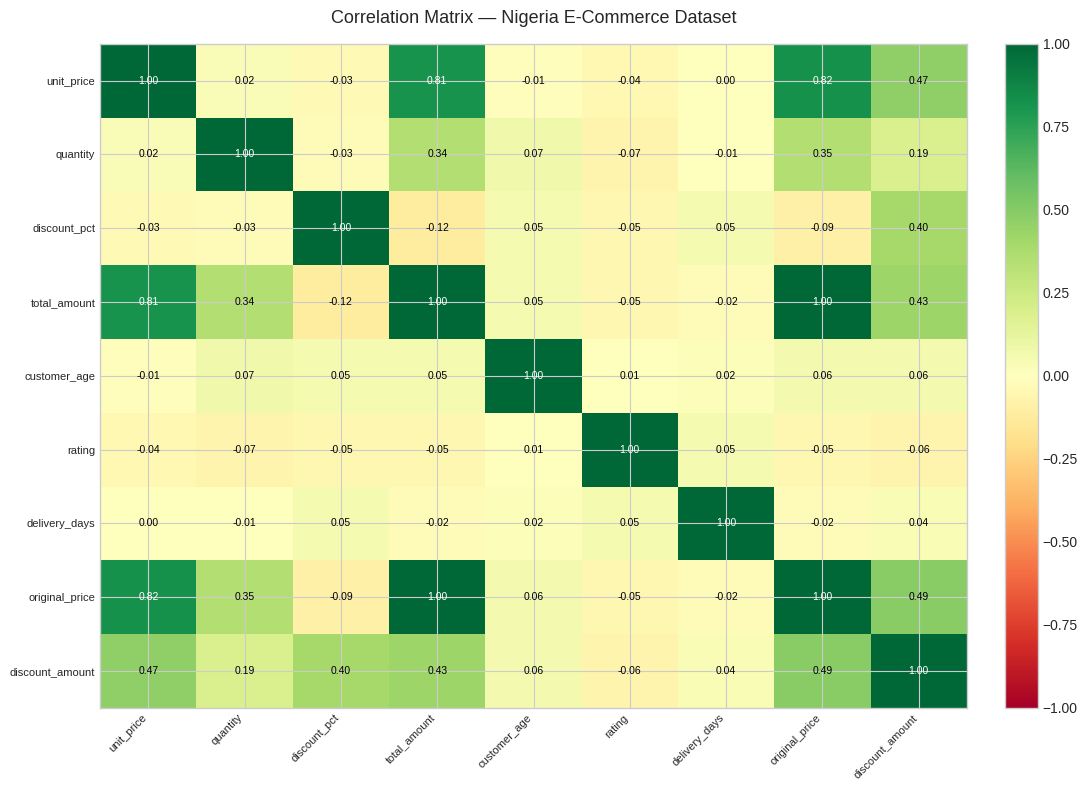

Heatmap saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.3 — Correlation Heatmap
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 8))

# Use imshow to render the correlation matrix as a colour grid
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Set axis labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

# Annotate each cell with the correlation value
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.values[i, j]
        colour = 'white' if abs(val) >= 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, color=colour)

ax.set_title('Correlation Matrix — Nigeria E-Commerce Dataset', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

---
# SECTION 8: Data Visualisation with Pandas

---

## 8.1 Pandas Built-in Plotting

Pandas has a `.plot()` method that creates charts directly from DataFrames and Series. It is built on Matplotlib but much simpler.

### Available Chart Types

| Chart Type | `kind=` | Best For |
|---|---|---|
| Line | `'line'` | Trends over time |
| Bar | `'bar'` | Comparing categories |
| Horizontal bar | `'barh'` | Long category names |
| Histogram | `'hist'` | Distribution of numeric data |
| Box plot | `'box'` | Spread and outliers |
| Scatter | `'scatter'` | Relationship between two variables |
| Pie | `'pie'` | Part-to-whole |
| KDE | `'kde'` | Smooth distribution curve |

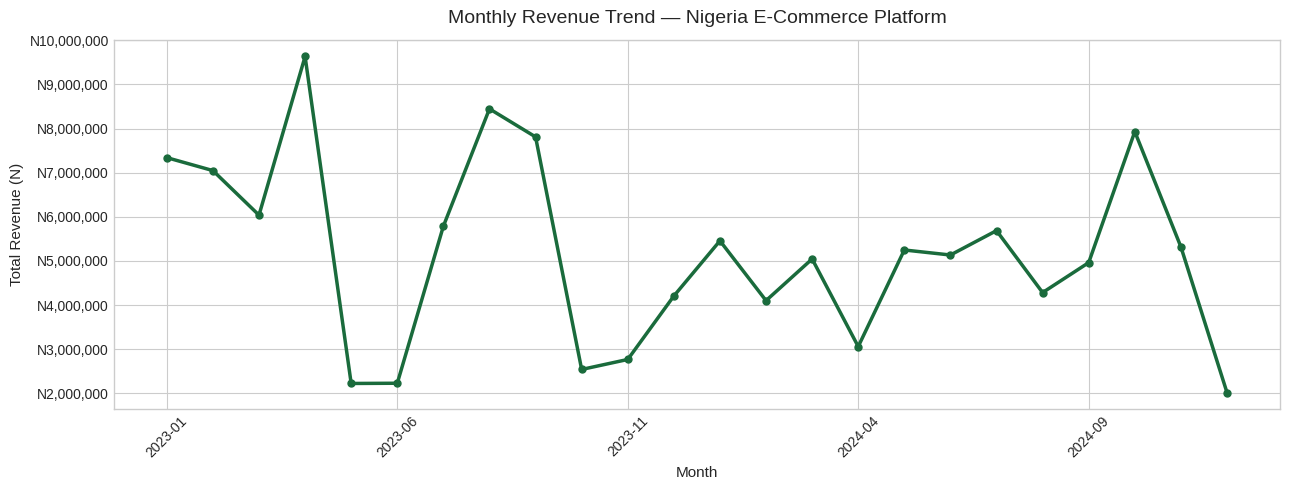

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.1 — Line Chart: Monthly Revenue Trend
# ─────────────────────────────────────────────────────────────────

df['year_month'] = df['order_date'].dt.to_period('M')
monthly_rev = df.groupby('year_month')['total_amount'].sum()
monthly_rev.index = monthly_rev.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
monthly_rev.plot(kind='line', ax=ax, color='#1a6b3c', linewidth=2.5, marker='o', markersize=5)

ax.set_title('Monthly Revenue Trend — Nigeria E-Commerce Platform', fontsize=14, pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Revenue (N)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x:,.0f}'))

plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

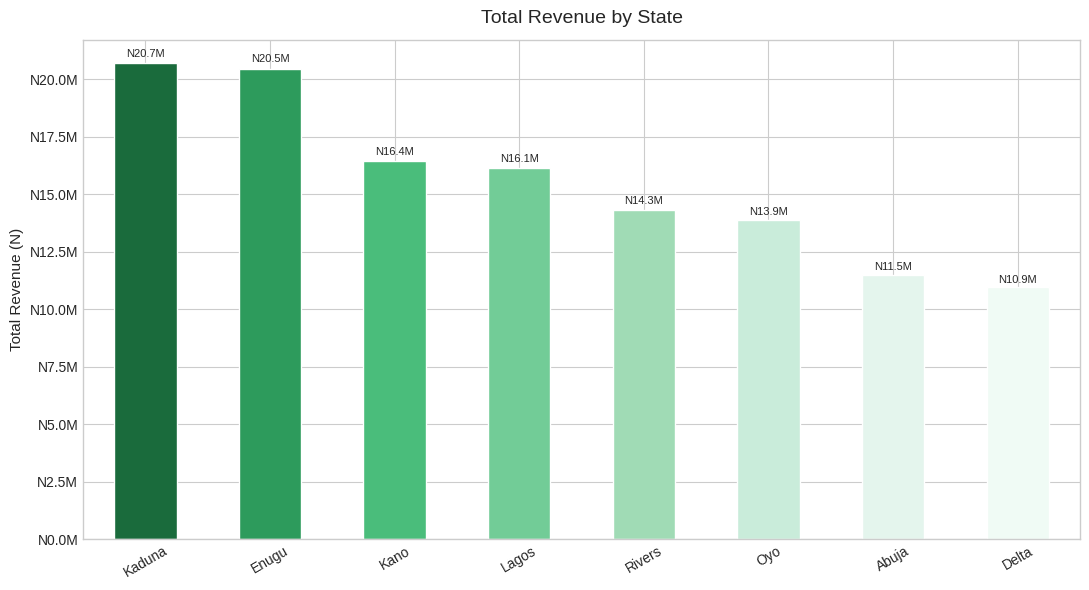

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.2 — Bar Chart: Revenue by State
# ─────────────────────────────────────────────────────────────────

state_rev = df.groupby('state')['total_amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#1a6b3c','#2d9b5c','#4abd7b','#72cc97','#a0dbb5','#c9ecda','#e4f5ed','#f0fbf5']
state_rev.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Total Revenue by State', fontsize=14, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (N)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

# Add value labels above each bar
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h * 1.01,
            f'N{h/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('revenue_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

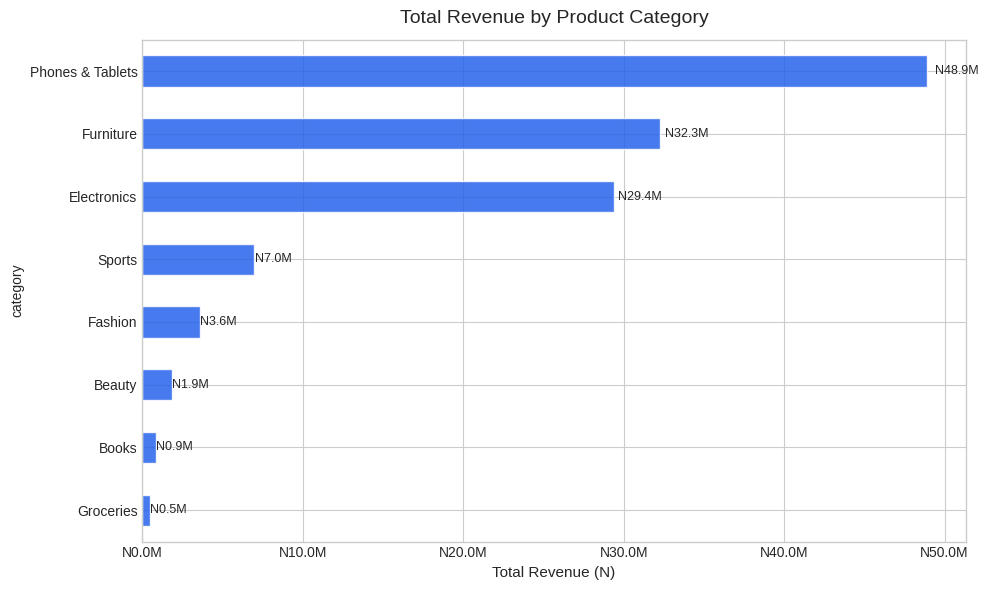

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.3 — Horizontal Bar Chart: Revenue by Category
# ─────────────────────────────────────────────────────────────────

cat_rev = df.groupby('category')['total_amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cat_rev.plot(kind='barh', ax=ax, color='#2563eb', alpha=0.85, edgecolor='white')

ax.set_title('Total Revenue by Product Category', fontsize=14, pad=12)
ax.set_xlabel('Total Revenue (N)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

for bar in ax.patches:
    w = bar.get_width()
    ax.text(w * 1.01, bar.get_y() + bar.get_height()/2,
            f'N{w/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

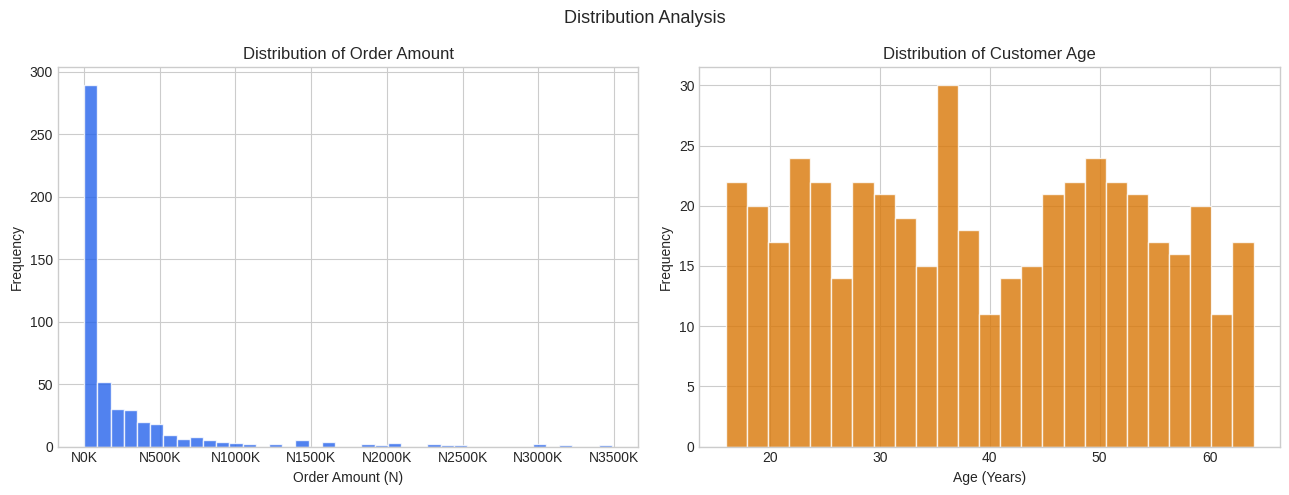

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.4 — Histograms: Distributions of Numeric Columns
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: distribution of total order amounts
df['total_amount'].plot(kind='hist', bins=40, ax=axes[0],
                        color='#2563eb', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution of Order Amount')
axes[0].set_xlabel('Order Amount (N)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1000:.0f}K'))

# Right: distribution of customer ages
df['customer_age'].dropna().plot(kind='hist', bins=25, ax=axes[1],
                                 color='#d97706', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribution of Customer Age')
axes[1].set_xlabel('Age (Years)')

plt.suptitle('Distribution Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_551/752804651.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(platform_groups, labels=platform_names, patch_artist=True)


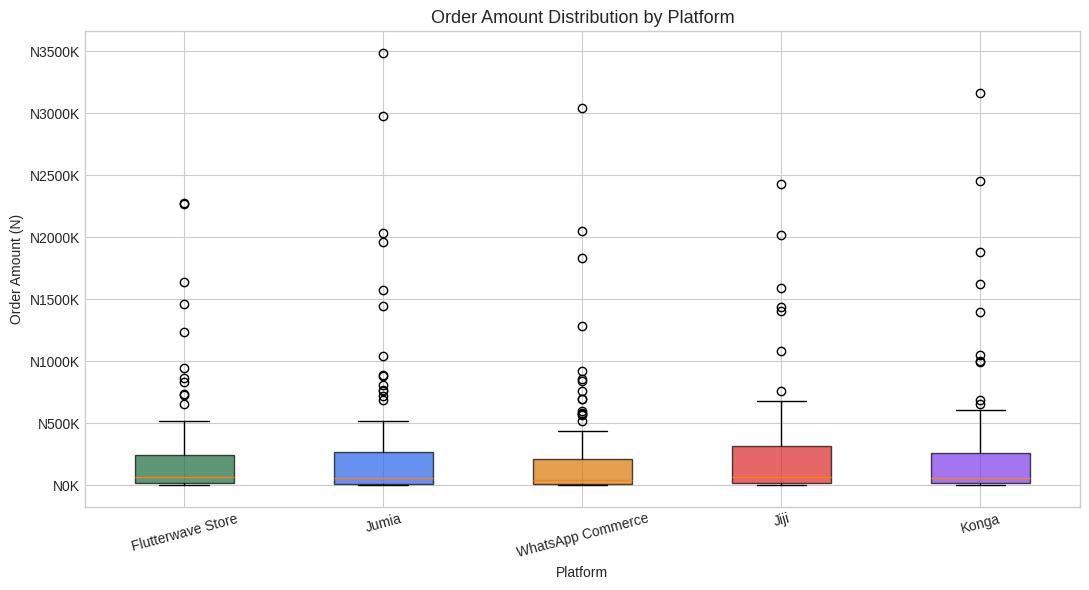

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.5 — Box Plot: Order Value by Platform
# ─────────────────────────────────────────────────────────────────

# Box plots show: median (middle line), IQR (box = 25th to 75th percentile),
# whiskers (1.5 x IQR), and individual outlier dots.

platform_groups = [df[df['platform'] == p]['total_amount'].dropna().values
                   for p in df['platform'].unique()]
platform_names  = df['platform'].unique().tolist()

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(platform_groups, labels=platform_names, patch_artist=True)

colors_box = ['#1a6b3c','#2563eb','#d97706','#dc2626','#7c3aed']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Order Amount Distribution by Platform', fontsize=13)
ax.set_xlabel('Platform')
ax.set_ylabel('Order Amount (N)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('boxplot_by_platform.png', dpi=150, bbox_inches='tight')
plt.show()

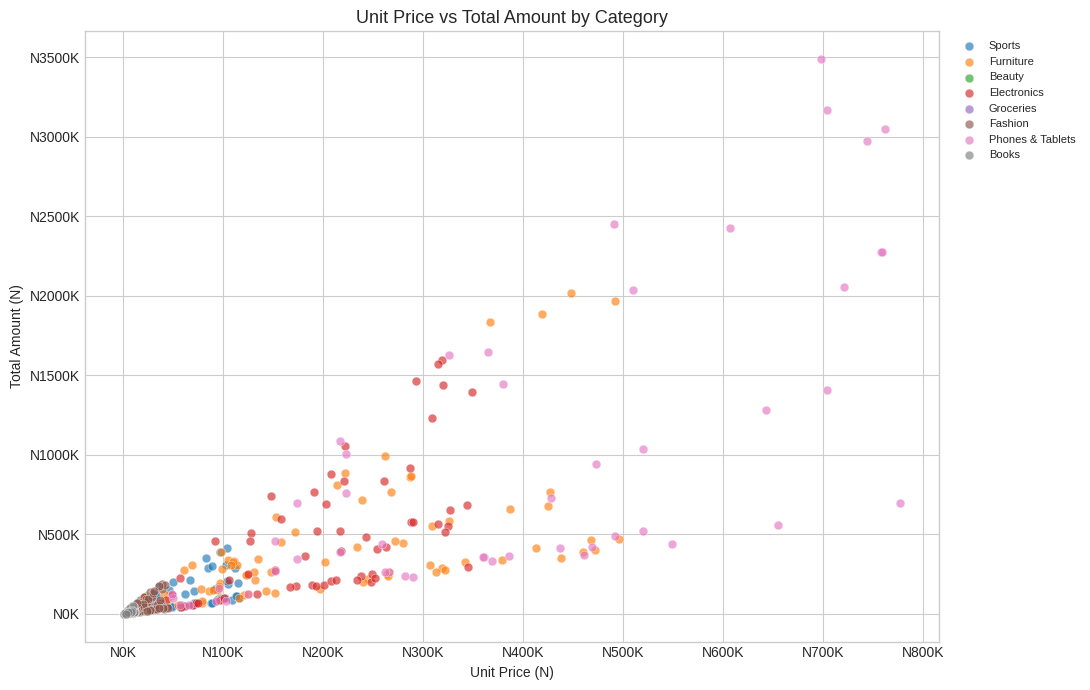

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.6 — Scatter Plot: Unit Price vs Total Amount by Category
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 7))
colours = plt.cm.tab10.colors

for i, cat in enumerate(df['category'].unique()):
    subset = df[df['category'] == cat]
    ax.scatter(subset['unit_price'], subset['total_amount'],
               label=cat, color=colours[i % 10], alpha=0.65, s=40,
               edgecolors='white', linewidth=0.4)

ax.set_title('Unit Price vs Total Amount by Category', fontsize=13)
ax.set_xlabel('Unit Price (N)')
ax.set_ylabel('Total Amount (N)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('scatter_price_vs_total.png', dpi=150, bbox_inches='tight')
plt.show()

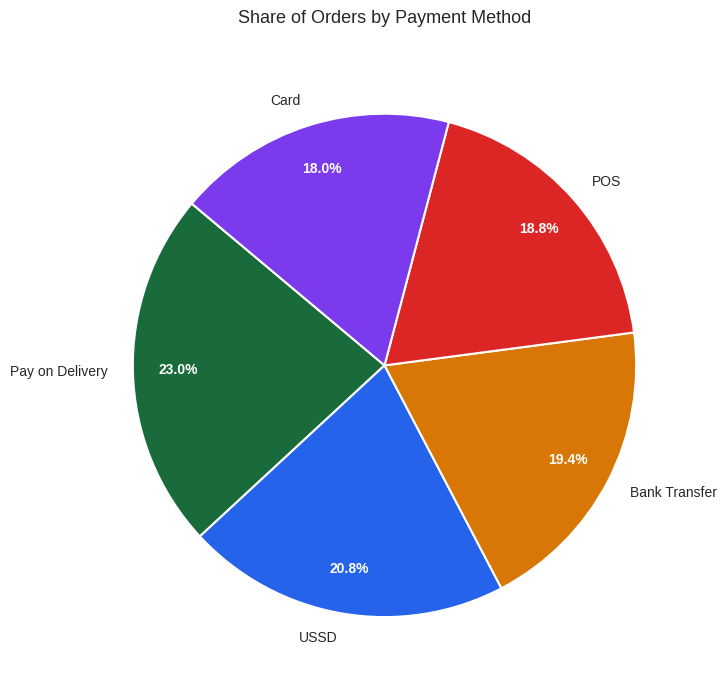

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.7 — Pie Chart: Payment Method Share
# ─────────────────────────────────────────────────────────────────

payment_counts = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    labels       = payment_counts.index,
    autopct      = '%1.1f%%',
    startangle   = 140,
    colors       = ['#1a6b3c','#2563eb','#d97706','#dc2626','#7c3aed'],
    pctdistance  = 0.82,
    wedgeprops   = dict(linewidth=1.5, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Share of Orders by Payment Method', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('payment_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

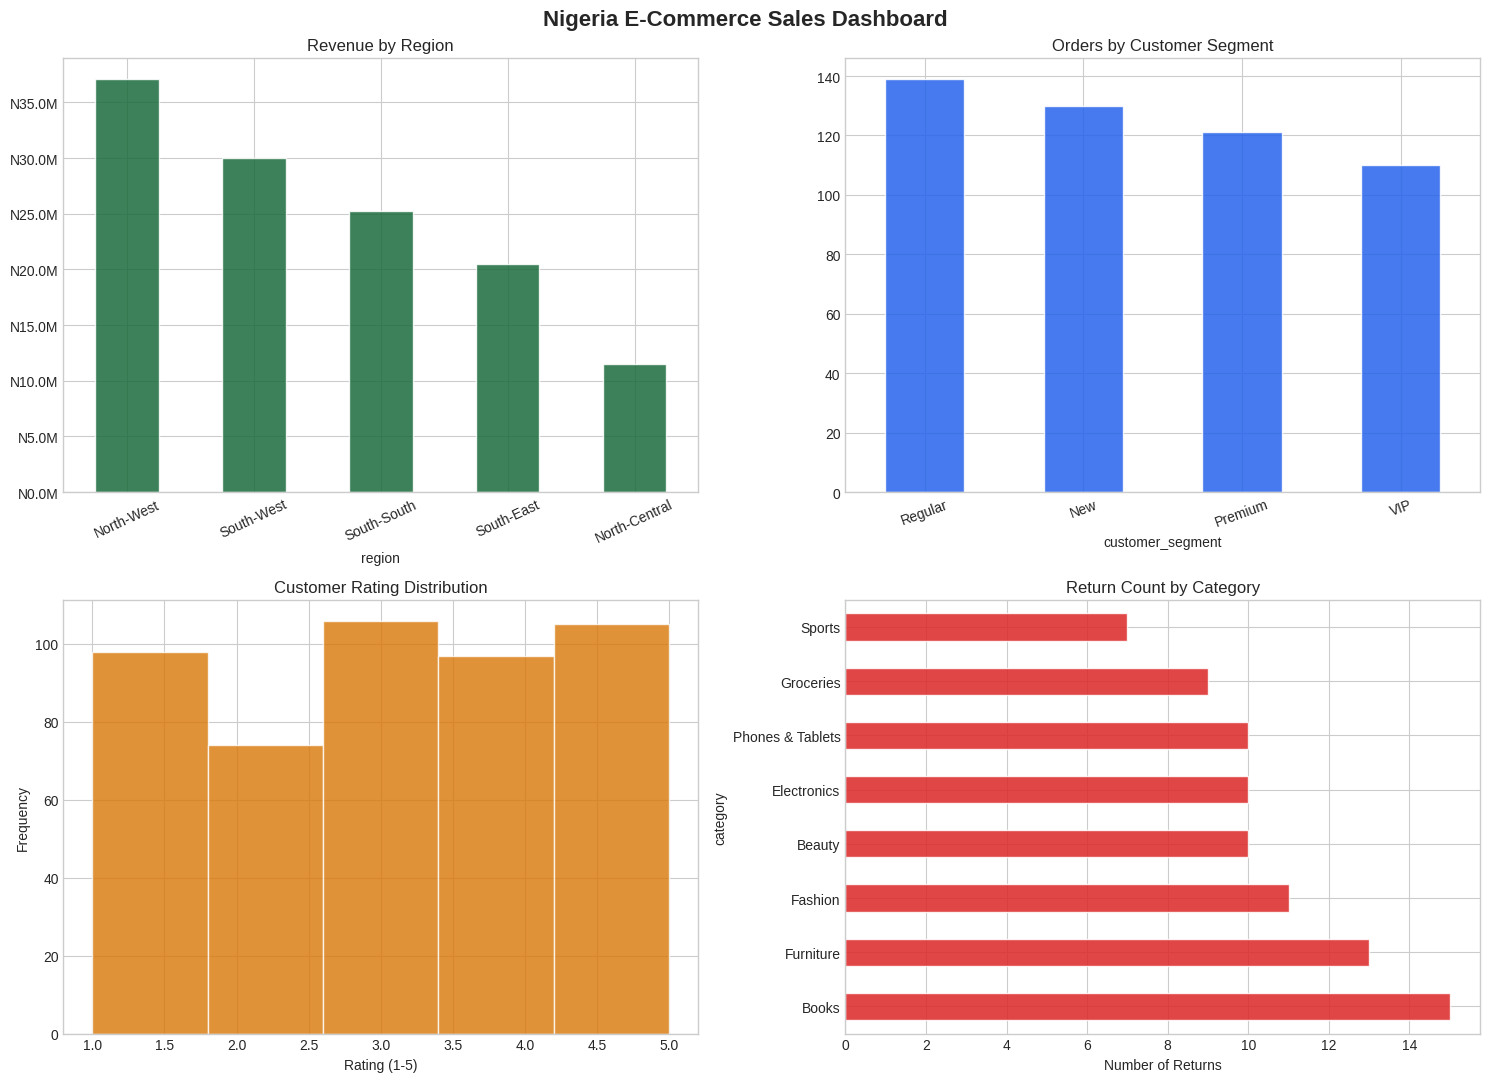

Dashboard saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.8 — 2x2 Dashboard: Four Charts in One Figure
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Nigeria E-Commerce Sales Dashboard', fontsize=16, fontweight='bold')

# Top-left: Revenue by region
region_rev = df.groupby('region')['total_amount'].sum().sort_values(ascending=False)
region_rev.plot(kind='bar', ax=axes[0,0], color='#1a6b3c', alpha=0.85, edgecolor='white')
axes[0,0].set_title('Revenue by Region')
axes[0,0].tick_params(axis='x', rotation=25)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

# Top-right: Orders by customer segment
seg_counts = df['customer_segment'].value_counts()
seg_counts.plot(kind='bar', ax=axes[0,1], color='#2563eb', alpha=0.85, edgecolor='white')
axes[0,1].set_title('Orders by Customer Segment')
axes[0,1].tick_params(axis='x', rotation=20)

# Bottom-left: Rating distribution
df['rating'].dropna().plot(kind='hist', bins=5, ax=axes[1,0],
                           color='#d97706', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Customer Rating Distribution')
axes[1,0].set_xlabel('Rating (1-5)')

# Bottom-right: Return count by category
returns = df.groupby('category')['returned'].sum().sort_values(ascending=False)
returns.plot(kind='barh', ax=axes[1,1], color='#dc2626', alpha=0.85, edgecolor='white')
axes[1,1].set_title('Return Count by Category')
axes[1,1].set_xlabel('Number of Returns')

plt.tight_layout()
plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

---
# SECTION 9: Advanced Pandas Topics

---

## 9.1 Merging and Joining DataFrames

In the real world, data is rarely all in one table. You often need to combine data from multiple sources.

| Function | Description | SQL Equivalent |
|---|---|---|
| `pd.merge()` | Combine DataFrames by matching column values | JOIN |
| `pd.concat()` | Stack DataFrames vertically or horizontally | UNION |

### Merge Types (same as SQL JOINs)

| how= | Returns |
|---|---|
| `'inner'` | Only rows with a match in BOTH DataFrames |
| `'left'` | All rows from left, NaN where no match in right |
| `'right'` | All rows from right, NaN where no match in left |
| `'outer'` | All rows from both, NaN where no match |

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.1 — pd.merge(): Combining Two DataFrames by Key
# ─────────────────────────────────────────────────────────────────

# Create a supplementary lookup table with regional economic data
regional_info = pd.DataFrame({
    'region'                  : ['South-West','North-Central','North-West','South-South','South-East'],
    'regional_gdp_bn'         : [42.5, 18.3, 12.1, 28.7, 15.9],
    'internet_penetration_pct': [78,   61,   45,   72,   68  ],
    'regional_manager'        : ['Adebayo Okafor','Mohammed Tanko','Aisha Garba','Emeka Obi','Chioma Eze']
})

print("=== Regional Info Table ===")
print(regional_info)
print()

# LEFT JOIN: keep all rows from df, add matching columns from regional_info
df_merged = pd.merge(df, regional_info, on='region', how='left')

print(f"Merged shape: {df_merged.shape}")
print(df_merged[['order_id','state','region','regional_gdp_bn','internet_penetration_pct']].head(5))

=== Regional Info Table ===
          region  regional_gdp_bn  internet_penetration_pct regional_manager
0     South-West             42.5                        78   Adebayo Okafor
1  North-Central             18.3                        61   Mohammed Tanko
2     North-West             12.1                        45      Aisha Garba
3    South-South             28.7                        72        Emeka Obi
4     South-East             15.9                        68       Chioma Eze

Merged shape: (500, 33)
     order_id   state       region  regional_gdp_bn  internet_penetration_pct
0  ORD-100000  Kaduna   North-West             12.1                        45
1  ORD-100001  Rivers  South-South             28.7                        72
2  ORD-100002     Oyo   South-West             42.5                        78
3  ORD-100003  Kaduna   North-West             12.1                        45
4  ORD-100004    Kano   North-West             12.1                        45


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.2 — pd.concat(): Stacking DataFrames
# ─────────────────────────────────────────────────────────────────

# Split dataset into two halves, then stack them back together
first_half  = df.iloc[:len(df)//2]
second_half = df.iloc[len(df)//2:]

print(f"First half : {len(first_half)} rows")
print(f"Second half: {len(second_half)} rows")

# axis=0 (default): vertical stacking — add more rows
df_reunited = pd.concat([first_half, second_half], ignore_index=True)
print(f"Reunited   : {len(df_reunited)} rows")
print()

# axis=1: horizontal stacking — add more columns
extra = pd.DataFrame({
    'loyalty_points'    : np.random.randint(100, 5000, len(df)),
    'preferred_contact' : np.random.choice(['Email','SMS','WhatsApp'], len(df))
})
df_h = pd.concat([df[['order_id','state','total_amount']], extra], axis=1)
print("=== Horizontal concat ===")
print(df_h.head(4))

First half : 250 rows
Second half: 250 rows
Reunited   : 500 rows

=== Horizontal concat ===
     order_id   state  total_amount  loyalty_points preferred_contact
0  ORD-100000  Kaduna     287928.73            4489          WhatsApp
1  ORD-100001  Rivers     447433.23            4262               SMS
2  ORD-100002     Oyo     516076.86            2606               SMS
3  ORD-100003  Kaduna      87098.82            2298               SMS


---
## 9.2 Time Series Analysis

Pandas has exceptional support for time series data — any data indexed by time (daily sales, monthly revenue, hourly readings).

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.3 — resample(): Aggregating by Time Frequency
# ─────────────────────────────────────────────────────────────────

# Set order_date as the index for time series operations
df_ts = df.set_index('order_date').sort_index()

# resample() groups by a time frequency — like groupby for dates.
# Key frequencies: 'D'=day, 'W'=week, 'ME'=month-end, 'QE'=quarter-end

# Monthly statistics
monthly_stats = df_ts['total_amount'].resample('ME').agg(
    orders    = 'count',
    revenue   = 'sum',
    avg_order = 'mean'
).round(2)

print("=== Monthly Statistics (first 12 months) ===")
print(monthly_stats.head(12))

=== Monthly Statistics (first 12 months) ===
            orders     revenue  avg_order
order_date                               
2023-01-31      22  7340303.44  333650.16
2023-02-28      19  7046958.49  370892.55
2023-03-31      21  6037566.95  287503.19
2023-04-30      21  9632560.55  458693.36
2023-05-31      21  2223613.09  105886.34
2023-06-30      20  2228650.48  111432.52
2023-07-31      21  5786504.93  275547.85
2023-08-31      22  8445694.53  383895.21
2023-09-30      20  7809715.51  390485.78
2023-10-31      21  2540893.08  120994.91
2023-11-30      21  2767363.73  131779.23
2023-12-31      21  4205099.73  200242.84


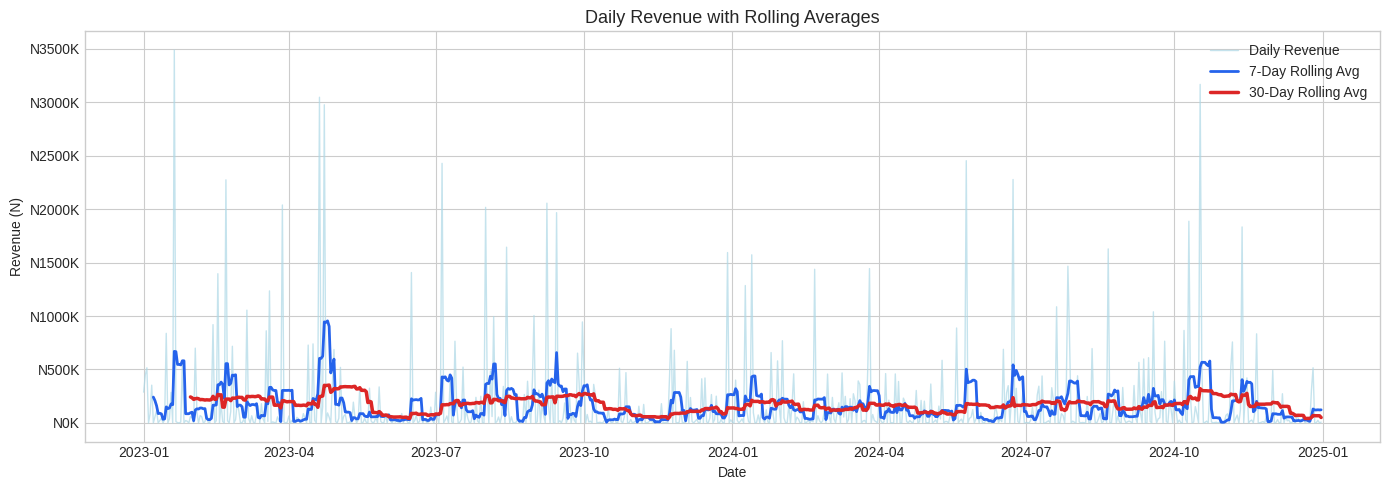

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.4 — Rolling Averages (Moving Average)
# ─────────────────────────────────────────────────────────────────

# A rolling/moving average smooths short-term fluctuations
# to reveal the underlying trend. Essential in financial analysis.

daily_revenue = df_ts['total_amount'].resample('D').sum().fillna(0)
rolling_7d    = daily_revenue.rolling(window=7).mean()
rolling_30d   = daily_revenue.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_revenue.index, daily_revenue.values,
        color='lightblue', linewidth=1, alpha=0.7, label='Daily Revenue')
ax.plot(rolling_7d.index, rolling_7d.values,
        color='#2563eb', linewidth=2, label='7-Day Rolling Avg')
ax.plot(rolling_30d.index, rolling_30d.values,
        color='#dc2626', linewidth=2.5, label='30-Day Rolling Avg')

ax.set_title('Daily Revenue with Rolling Averages', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (N)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('rolling_average.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9.3 MultiIndex DataFrames

A **MultiIndex** (hierarchical index) allows a DataFrame to have two or more levels of row labels. Very useful for grouped or nested data.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.5 — Creating and Querying a MultiIndex DataFrame
# ─────────────────────────────────────────────────────────────────

# Group by region AND category simultaneously
multi = df.groupby(['region', 'category']).agg(
    orders        = ('order_id',    'count'),
    total_revenue = ('total_amount','sum'  ),
    avg_rating    = ('rating',      'mean' )
).round(2)

print("=== MultiIndex DataFrame ===")
print(multi.head(10))
print()
print("Index levels:", multi.index.names)
print()

# Access a specific top-level group using .loc
print("=== South-West region only ===")
print(multi.loc['South-West'])

=== MultiIndex DataFrame ===
                                orders  total_revenue  avg_rating
region        category                                           
North-Central Beauty                 1       15083.78        1.00
              Books                  4       60504.89        3.00
              Electronics            6     1923872.76        2.50
              Fashion                7      366356.31        3.43
              Furniture              8     2286905.09        3.14
              Groceries              7       45599.36        3.43
              Phones & Tablets       6     6125139.93        2.00
              Sports                 7      659009.84        2.71
North-West    Beauty                 9      358216.05        3.14
              Books                 20      217273.79        2.89

Index levels: ['region', 'category']

=== South-West region only ===
                  orders  total_revenue  avg_rating
category                                           
Beaut

---
## 9.4 Advanced String Operations

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.6 — String Operations: extract, split, contains
# ─────────────────────────────────────────────────────────────────

# Extract the numeric order number from 'ORD-100042' -> '100042'
df['order_number'] = df['order_id'].str.replace('ORD-', '', regex=False)
print("Extracted order numbers:")
print(df[['order_id', 'order_number']].head(5))
print()

# str.split() splits a string on a delimiter
demo = pd.Series(['Lagos-SW', 'Abuja-NC', 'Kano-NW', 'Rivers-SS'])
split_df = demo.str.split('-', expand=True)   # expand=True creates multiple columns
split_df.columns = ['city', 'zone']
print("=== String Split ===")
print(split_df)
print()

# str.contains(): partial match — returns a boolean Series
tech_mask = df['category'].str.contains('Electronics|Phones', na=False)
print(f"Electronics or Phones orders: {tech_mask.sum()}")

Extracted order numbers:
     order_id order_number
0  ORD-100000       100000
1  ORD-100001       100001
2  ORD-100002       100002
3  ORD-100003       100003
4  ORD-100004       100004

=== String Split ===
     city zone
0   Lagos   SW
1   Abuja   NC
2    Kano   NW
3  Rivers   SS

Electronics or Phones orders: 113


---
## 9.5 Ranking and Cumulative Operations

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.7 — rank() and nlargest() / nsmallest()
# ─────────────────────────────────────────────────────────────────

# rank() assigns a rank to each value
df['revenue_rank'] = df['total_amount'].rank(ascending=False, method='dense').astype(int)

# nlargest() — the top n rows by a column (faster than sort + head)
top5 = df.nlargest(5, 'total_amount')[['order_id','state','category','total_amount','revenue_rank']]
print("=== Top 5 Orders by Revenue ===")
print(top5)
print()

# Rank WITHIN each state group using groupby + rank
df['rank_in_state'] = df.groupby('state')['total_amount'].rank(ascending=False, method='dense')
print("=== Per-State Revenue Rank (first 10 rows) ===")
print(df[['order_id','state','total_amount','rank_in_state']].head(10))

=== Top 5 Orders by Revenue ===
       order_id   state          category  total_amount  revenue_rank
13   ORD-100013    Kano  Phones & Tablets    3487694.40             1
448  ORD-100448  Kaduna  Phones & Tablets    3165866.60             2
75   ORD-100075   Abuja  Phones & Tablets    3045533.12             3
77   ORD-100077  Rivers  Phones & Tablets    2975358.12             4
349  ORD-100349  Kaduna  Phones & Tablets    2452347.70             5

=== Per-State Revenue Rank (first 10 rows) ===
     order_id   state  total_amount  rank_in_state
0  ORD-100000  Kaduna     287928.73           17.0
1  ORD-100001  Rivers     447433.23            9.0
2  ORD-100002     Oyo     516076.86            7.0
3  ORD-100003  Kaduna      87098.82           28.0
4  ORD-100004    Kano     353232.59           13.0
5  ORD-100005   Enugu      55581.34           39.0
6  ORD-100006     Oyo     114222.20           18.0
7  ORD-100007     Oyo      22674.70           31.0
8  ORD-100008  Kaduna      45191.80      

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.8 — Cumulative Operations: cumsum, expanding
# ─────────────────────────────────────────────────────────────────

# cumsum() computes a running total — widely used for growth charts
df_sorted = df.sort_values('order_date').copy()
df_sorted['cumulative_revenue'] = df_sorted['total_amount'].cumsum()
df_sorted['running_avg']        = df_sorted['total_amount'].expanding().mean()

print("=== Running Totals (first 10 orders chronologically) ===")
print(df_sorted[['order_date','total_amount','cumulative_revenue','running_avg']].head(10).round(2))

=== Running Totals (first 10 orders chronologically) ===
  order_date  total_amount  cumulative_revenue  running_avg
0 2023-01-01     287928.73           287928.73    287928.73
1 2023-01-02     447433.23           735361.96    367680.98
2 2023-01-03     516076.86          1251438.82    417146.27
3 2023-01-05      87098.82          1338537.64    334634.41
4 2023-01-06     353232.59          1691770.23    338354.05
5 2023-01-08      55581.34          1747351.57    291225.26
6 2023-01-09     114222.20          1861573.77    265939.11
7 2023-01-11      22674.70          1884248.47    235531.06
8 2023-01-12      45191.80          1929440.27    214382.25
9 2023-01-14      31675.93          1961116.20    196111.62


/tmp/ipykernel_551/2964214242.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_sorted[['order_date','total_amount','cumulative_revenue','running_avg']].head(10).round(2))


---
## 9.6 Wide vs Long Data: melt() and pivot()

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.9 — melt(): Wide Format to Long Format
# ─────────────────────────────────────────────────────────────────

# Data can be WIDE (each metric = a column) or LONG (each metric = a row).
#
# WIDE is good for pivot tables and Excel reports.
# LONG is good for analysis, groupby, and charting.
#
# melt() converts WIDE to LONG.

wide = df.groupby('state').agg(
    total_revenue = ('total_amount','sum'  ),
    total_orders  = ('order_id',   'count'),
    avg_order_val = ('total_amount','mean' )
).reset_index().round(2)

print("=== Wide Format ===")
print(wide)
print()

long = wide.melt(id_vars='state', var_name='metric', value_name='value')
print("=== Long Format (after melt) ===")
print(long.head(15))

=== Wide Format ===
    state  total_revenue  total_orders  avg_order_val
0   Abuja    11482471.96            46      249618.96
1   Delta    10948343.07            62      176586.18
2   Enugu    20455844.87            72      284108.96
3  Kaduna    20677285.25            58      356504.92
4    Kano    16425359.96            64      256646.25
5   Lagos    16138923.60            71      227308.78
6     Oyo    13857110.95            51      271708.06
7  Rivers    14320532.67            76      188428.06

=== Long Format (after melt) ===
     state         metric        value
0    Abuja  total_revenue  11482471.96
1    Delta  total_revenue  10948343.07
2    Enugu  total_revenue  20455844.87
3   Kaduna  total_revenue  20677285.25
4     Kano  total_revenue  16425359.96
5    Lagos  total_revenue  16138923.60
6      Oyo  total_revenue  13857110.95
7   Rivers  total_revenue  14320532.67
8    Abuja   total_orders        46.00
9    Delta   total_orders        62.00
10   Enugu   total_orders      

---
# SECTION 10: Real-World Case Study — End-to-End Business Analysis

---

## The Business Question

You have been hired as a Data Analyst by a Nigerian e-commerce holding company. Your manager has asked for a **performance report** answering:

1. Which states and regions generate the most revenue?
2. Which product categories perform best?
3. What is the return rate by category?
4. Which customer segments are most valuable?
5. Is there a correlation between discounts and ratings?
6. What are the revenue trends over time?

We answer all of these end-to-end with Pandas.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.1 — Reload, Clean, and Enrich the Dataset
# ─────────────────────────────────────────────────────────────────

# Reload and apply all cleaning steps in a pipeline
df_f = pd.read_csv('nigeria_ecommerce_sales.csv', parse_dates=['order_date'])
df_f.drop_duplicates(inplace=True)
df_f.reset_index(drop=True, inplace=True)

# Fix dirty delivery_days
df_f['delivery_days'] = df_f['delivery_days'].where(df_f['delivery_days'] <= 30, np.nan)
df_f['delivery_days'].fillna(df_f['delivery_days'].median(), inplace=True)

# Fill missing numeric columns with median
df_f['customer_age'].fillna(df_f['customer_age'].median(), inplace=True)
df_f['rating'].fillna(df_f['rating'].mean(), inplace=True)

# Feature engineering
df_f['original_price']  = df_f['unit_price'] * df_f['quantity']
df_f['discount_amount'] = df_f['original_price'] - df_f['total_amount']
df_f['year_month']      = df_f['order_date'].dt.to_period('M').astype(str)
df_f['quarter']         = 'Q' + df_f['order_date'].dt.quarter.astype(str) +                           '-' + df_f['order_date'].dt.year.astype(str)

print("=== Clean & Enriched Dataset ===")
print(f"Shape: {df_f.shape}")
print(f"Missing values remaining: {df_f.isnull().sum().sum()}")
print(df_f.head(3))

=== Clean & Enriched Dataset ===
Shape: (500, 22)
Missing values remaining: 50
     order_id order_date   state       region           platform   category  \
0  ORD-100000 2023-01-01  Kaduna   North-West  Flutterwave Store     Sports   
1  ORD-100001 2023-01-02  Rivers  South-South  Flutterwave Store  Furniture   
2  ORD-100002 2023-01-03     Oyo   South-West              Jumia  Furniture   

  product_name  unit_price  quantity  discount_pct  ...  customer_age  \
0    Product_0    84684.92         4            15  ...          51.0   
1    Product_1   279645.77         2            20  ...          45.0   
2    Product_2   172025.62         3             0  ...          33.0   

  customer_gender  customer_segment rating delivery_days  returned  \
0            Male           Premium    4.0           9.0     False   
1          Female               VIP    NaN           1.0     False   
2          Female               New    3.0          11.0     False   

   original_price  discount_am

/tmp/ipykernel_551/613209492.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_f['delivery_days'].fillna(df_f['delivery_days'].median(), inplace=True)
/tmp/ipykernel_551/613209492.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inpla

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.2 — Q1: Revenue by State and Region
# ─────────────────────────────────────────────────────────────────

state_report = df_f.groupby(['region','state']).agg(
    orders     = ('order_id',    'count'),
    revenue    = ('total_amount','sum'  ),
    avg_order  = ('total_amount','mean' ),
    avg_rating = ('rating',      'mean' )
).round(2).sort_values('revenue', ascending=False)

print("=== Revenue Report by State & Region ===")
print(state_report.to_string())

=== Revenue Report by State & Region ===
                      orders      revenue  avg_order  avg_rating
region        state                                             
North-West    Kaduna      58  20677285.25  356504.92        3.07
South-East    Enugu       72  20455844.87  284108.96        3.14
North-West    Kano        64  16425359.96  256646.25        3.14
South-West    Lagos       71  16138923.60  227308.78        3.16
South-South   Rivers      76  14320532.67  188428.06        3.08
South-West    Oyo         51  13857110.95  271708.06        3.10
North-Central Abuja       46  11482471.96  249618.96        2.87
South-South   Delta       62  10948343.07  176586.18        2.98


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.3 — Q2: Category Performance
# ─────────────────────────────────────────────────────────────────

cat_report = df_f.groupby('category').agg(
    orders        = ('order_id',    'count'),
    total_revenue = ('total_amount','sum'  ),
    avg_price     = ('unit_price',  'mean' ),
    avg_qty       = ('quantity',    'mean' ),
    avg_discount  = ('discount_pct','mean' ),
    avg_rating    = ('rating',      'mean' )
).round(2).sort_values('total_revenue', ascending=False)

cat_report['revenue_share_%'] = (cat_report['total_revenue'] /
                                   cat_report['total_revenue'].sum() * 100).round(1)

print("=== Category Performance Report ===")
print(cat_report.to_string())

=== Category Performance Report ===
                  orders  total_revenue  avg_price  avg_qty  avg_discount  avg_rating  revenue_share_%
category                                                                                              
Phones & Tablets      51    48883915.56  391170.83     2.37          6.18        3.02             39.3
Furniture             74    32276934.28  220862.92     2.20          7.84        3.07             26.0
Electronics           62    29371061.17  195523.87     2.48          7.02        3.00             23.6
Sports                61     6951281.41   59634.87     2.34          7.87        3.10              5.6
Fashion               71     3590355.11   22826.43     2.44          8.38        2.84              2.9
Beauty                62     1852506.78   13728.34     2.37          6.94        3.07              1.5
Books                 70      875364.24    6342.40     2.11          6.64        3.25              0.7
Groceries             49      504453.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.4 — Q3: Return Rate by Category
# ─────────────────────────────────────────────────────────────────

returns = df_f.groupby('category').agg(
    total_orders = ('order_id', 'count'),
    returned     = ('returned', 'sum')
).assign(
    return_rate_pct = lambda x: (x['returned'] / x['total_orders'] * 100).round(1)
).sort_values('return_rate_pct', ascending=False)

print("=== Return Rate by Category ===")
print(returns)
print()
print(f"Overall platform return rate: {df_f['returned'].mean()*100:.1f}%")

=== Return Rate by Category ===
                  total_orders  returned  return_rate_pct
category                                                 
Books                       70        15             21.4
Phones & Tablets            51        10             19.6
Groceries                   49         9             18.4
Furniture                   74        13             17.6
Beauty                      62        10             16.1
Electronics                 62        10             16.1
Fashion                     71        11             15.5
Sports                      61         7             11.5

Overall platform return rate: 17.0%


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.5 — Q4: Customer Segment Value Analysis
# ─────────────────────────────────────────────────────────────────

seg = df_f.groupby('customer_segment').agg(
    orders        = ('order_id',    'count'),
    total_revenue = ('total_amount','sum'  ),
    avg_order_val = ('total_amount','mean' ),
    avg_rating    = ('rating',      'mean' ),
    return_rate   = ('returned',    'mean' )
).round(3).sort_values('total_revenue', ascending=False)

seg['return_rate'] = (seg['return_rate'] * 100).round(1)

print("=== Customer Segment Report ===")
print(seg.to_string())

=== Customer Segment Report ===
                  orders  total_revenue  avg_order_val  avg_rating  return_rate
customer_segment                                                               
Regular              139    35499164.52     255389.673       2.992         16.5
New                  130    30649912.72     235768.559       3.103         20.0
Premium              121    30232813.74     249857.965       3.017         13.2
VIP                  110    27923981.35     253854.376       3.215         18.2


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.6 — Q5: Do Discounts Affect Ratings?
# ─────────────────────────────────────────────────────────────────

corr_val = df_f['discount_pct'].corr(df_f['rating'])
print(f"Correlation — discount_pct vs rating: {corr_val:.4f}")
print()

# Average rating at each discount level
rating_by_disc = df_f.groupby('discount_pct')['rating'].agg(['mean','count']).round(3)
rating_by_disc.columns = ['avg_rating', 'count']
print("=== Average Rating by Discount Level ===")
print(rating_by_disc)

Correlation — discount_pct vs rating: -0.0487

=== Average Rating by Discount Level ===
              avg_rating  count
discount_pct                   
0                  3.176    199
5                  3.014     72
10                 3.015     68
15                 2.986     72
20                 3.014     69


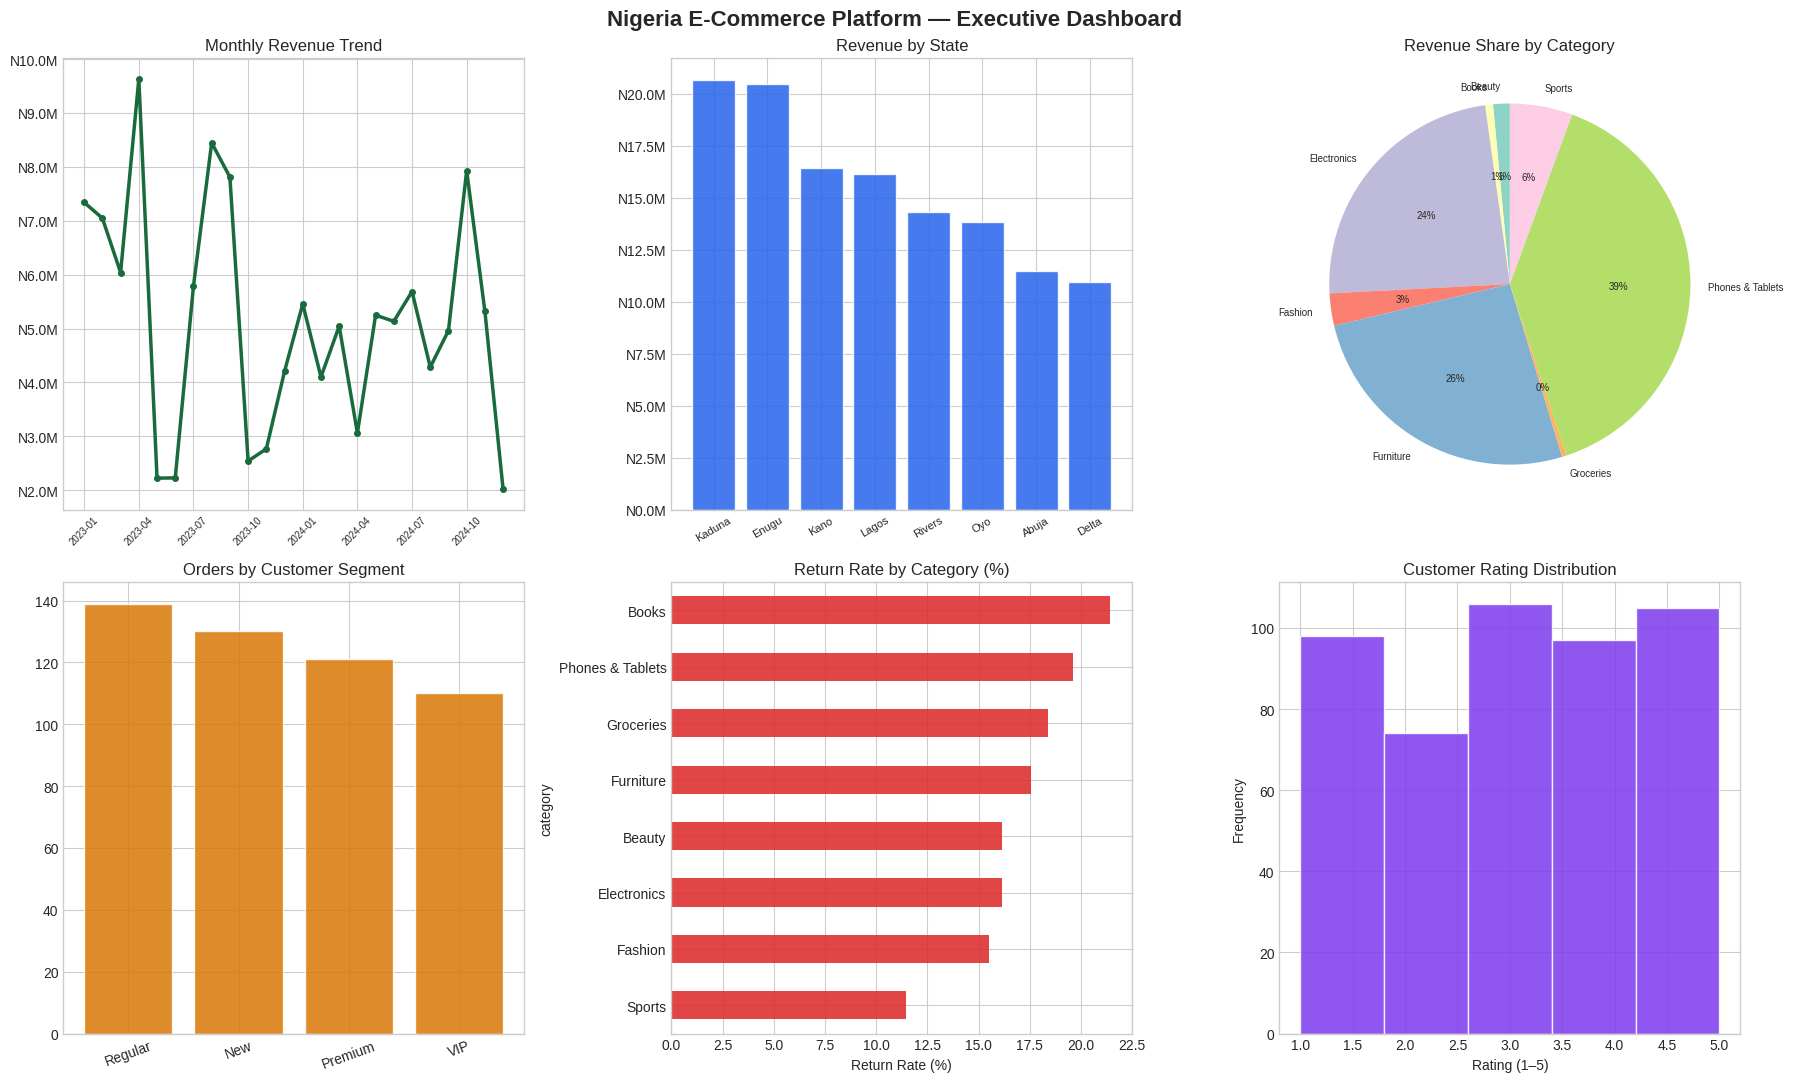

Executive dashboard saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.7 — Q6: Executive Dashboard (Final Chart)
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Nigeria E-Commerce Platform — Executive Dashboard', fontsize=16, fontweight='bold')

# 1 — Monthly revenue trend
monthly = df_f.groupby('year_month')['total_amount'].sum()
axes[0,0].plot(range(len(monthly)), monthly.values, color='#1a6b3c', linewidth=2.5, marker='o', markersize=4)
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_xticks(range(0, len(monthly), 3))
axes[0,0].set_xticklabels(monthly.index.tolist()[::3], rotation=45, fontsize=7)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

# 2 — Revenue by state
st = df_f.groupby('state')['total_amount'].sum().sort_values(ascending=False)
axes[0,1].bar(st.index, st.values, color='#2563eb', alpha=0.85, edgecolor='white')
axes[0,1].set_title('Revenue by State')
axes[0,1].tick_params(axis='x', rotation=30, labelsize=8)
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

# 3 — Category revenue share (pie)
cat_rev = df_f.groupby('category')['total_amount'].sum()
axes[0,2].pie(cat_rev.values, labels=cat_rev.index, autopct='%1.0f%%',
              startangle=90, colors=plt.cm.Set3.colors[:len(cat_rev)],
              textprops={'fontsize': 7})
axes[0,2].set_title('Revenue Share by Category')

# 4 — Orders by segment
seg_cnt = df_f['customer_segment'].value_counts()
axes[1,0].bar(seg_cnt.index, seg_cnt.values, color='#d97706', alpha=0.85, edgecolor='white')
axes[1,0].set_title('Orders by Customer Segment')
axes[1,0].tick_params(axis='x', rotation=20)

# 5 — Return rate by category
ret = df_f.groupby('category')['returned'].mean() * 100
ret.sort_values(ascending=True).plot(kind='barh', ax=axes[1,1], color='#dc2626', alpha=0.85)
axes[1,1].set_title('Return Rate by Category (%)')
axes[1,1].set_xlabel('Return Rate (%)')

# 6 — Rating distribution
df_f['rating'].plot(kind='hist', bins=5, ax=axes[1,2], color='#7c3aed', alpha=0.85, edgecolor='white')
axes[1,2].set_title('Customer Rating Distribution')
axes[1,2].set_xlabel('Rating (1–5)')

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Executive dashboard saved.")

---
# SECTION 11: Quick Reference — Pandas Cheat Sheet

---

## Loading Data
```python
pd.read_csv('file.csv')                                 # Load CSV
pd.read_csv('file.csv', parse_dates=['date_col'])       # Parse dates
pd.read_csv('file.csv', index_col='order_id')           # Use col as index
pd.read_excel('file.xlsx', sheet_name='Sheet1')         # Load Excel
pd.read_json('file.json')                               # Load JSON
```

## Inspecting Data
```python
df.head(n)             # First n rows
df.tail(n)             # Last n rows
df.sample(n)           # n random rows
df.info()              # Types + missing counts
df.describe()          # Statistical summary
df.shape               # (rows, columns)
df.dtypes              # Data type per column
df.columns.tolist()    # Column names as list
df.isnull().sum()      # Missing values per column
df.nunique()           # Unique value count per column
```

## Selecting Data
```python
df['col']                             # Single column (Series)
df[['col1','col2']]                   # Multiple columns (DataFrame)
df.loc[idx, 'col']                    # By label
df.iloc[row, col]                     # By integer position
df[df['col'] > value]                 # Boolean filter
df.query("col == 'value' and x > 5")  # String query
df['col'].isin(['a','b'])             # Multiple value match
```

## Cleaning Data
```python
df.isnull().sum()                       # Count missing values
df.fillna(value)                        # Fill NaN with constant
df['col'].fillna(df['col'].mean())      # Fill with mean
df.fillna(method='ffill')               # Forward fill
df.dropna()                             # Drop rows with any NaN
df.dropna(subset=['col'])               # Drop rows where col is NaN
df.drop_duplicates()                    # Remove duplicate rows
pd.to_datetime(df['col'])               # Convert to datetime
pd.to_numeric(series, errors='coerce')  # Convert to numeric
df['col'].str.strip().str.title()       # Strip whitespace, title case
df['col'].where(condition, np.nan)      # Replace values outside condition
```

## Creating New Columns
```python
df['new'] = df['a'] * df['b']                       # Arithmetic
df['new'] = np.where(condition, val_true, val_false) # Conditional (IF)
df['new'] = df['col'].apply(my_function)             # Apply function
pd.cut(df['col'], bins=[], labels=[])                # Bin to categories
pd.qcut(df['col'], q=4, labels=['Q1','Q2','Q3','Q4'])# Quartile bins
df['date_col'].dt.year                               # Extract year
df['date_col'].dt.month_name()                       # Extract month name
```

## Aggregating
```python
df['col'].sum() | mean() | median() | std() | min() | max()
df['col'].value_counts()
df.groupby('col')['other'].sum()
df.groupby('col').agg(
    new_name = ('source_col', 'function')
)
pd.pivot_table(df, values, index, columns, aggfunc)
```

## Merging and Stacking
```python
pd.merge(df1, df2, on='key', how='left')   # Left join
pd.merge(df1, df2, on='key', how='inner')  # Inner join
pd.concat([df1, df2], ignore_index=True)   # Stack rows
pd.concat([df1, df2], axis=1)              # Stack columns
df.melt(id_vars, var_name, value_name)     # Wide to long
```

## Time Series
```python
df.set_index('date_col').resample('ME').sum()      # Monthly total
series.rolling(window=7).mean()                    # 7-day rolling avg
series.expanding().mean()                          # Cumulative mean
df['date'].dt.year / .month / .day_name()          # Extract components
```

## Visualisation
```python
df['col'].plot(kind='line')        # Line chart
df['col'].plot(kind='bar')         # Bar chart
df['col'].plot(kind='hist', bins=30) # Histogram
df['col'].plot(kind='box')         # Box plot
df.plot.scatter('x_col', 'y_col')  # Scatter plot
df[cols].corr()                    # Correlation matrix
```

## Exporting
```python
df.to_csv('output.csv', index=False)
df.to_excel('output.xlsx', index=False, sheet_name='Report')
df.to_json('output.json', orient='records', indent=2)
```

---

## Your Learning Path from Here

1. **NumPy** — the numerical foundation under Pandas
2. **Matplotlib & Seaborn** — publication-quality visualisations
3. **Scikit-learn** — machine learning on your clean Pandas DataFrames
4. **SQL** — querying enterprise databases
5. **Power BI / Tableau** — business intelligence dashboards

---

> *"Data is the new oil — but only if you know how to refine it."*  
> Keep practising. Every dataset you clean and analyse makes you sharper.  
> — **Prodigy Training Hub**

---